In [1]:
# Presentation helpers — run once before entering slideshow mode
import warnings; warnings.filterwarnings("ignore")
import sys, os
# Ensure the graphed venv packages are importable
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "#1a1a2e", "axes.facecolor": "#16213e",
    "text.color": "white", "axes.labelcolor": "white",
    "axes.edgecolor": "#4ecdc4", "xtick.color": "white", "ytick.color": "white",
    "grid.color": "#2a2a4a", "grid.alpha": 0.4,
})
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np
print("Setup complete.")

Setup complete.


# graphed
## A Schedulable, Serializable, Debuggable
## HEP Task-Graph System

<br>

**Lindsey Gray** · Fermilab
Joint HEP × CS Seminar · June 25, 2026

<br>

> *"The middle path between dask-awkward (huge graphs, O(N²) optimization) and coffea 2025
> (discarded the schedulable graph)."*

## The LHC Analysis Challenge

| Scale | Number |
|---|---|
| Collisions recorded per second | ~40 M |
| Run 3 data per year | ~30 PB |
| Typical analysis dataset | 1–100 TB |
| Events after skimming | 10⁷ – 10⁹ |
| Output | **a few hundred histograms** |

<br>

**Standard workflow (NanoAOD era):**

```
ROOT files (NanoAOD)
    → partition into chunks (uproot)
        → apply cuts, corrections (awkward-array)
            → fill histograms (boost-histogram / UHI)
```

**The constraint:** every operation is over **ragged, variable-length arrays** per event
(each event has a different number of muons, jets, …)
→ cannot use simple numpy broadcasting across events

## Why a Task Graph?

**What we want:**
- Record the analysis *once*, run it on *many* partitions in parallel
- Optimize the graph before running (column projection, op fusion)
- Crash-safe resumption (petabyte datasets take hours)
- Deterministic, serializable output (reproducibility)
- Human-readable tracebacks (not "worker died on line 4 of a pickle")

**dask-awkward tried this — and taught us 8 failure modes:**

| # | Failure mode |
|---|---|
| 1 | Build the complete graph **before** optimizing — O(N²) on systematics |
| 2 | Record intent operator-by-operator → uncompacted giant low-level graph |
| 3 | Slow optimization dominating wall time |
| 4 | High local memory: full graph + optimizer state |
| 5 | Unclear packaging of external payloads (e.g. an NN) for parallel execution |
| 6 | Low-level graphs so large the Python interpreter itself is a cost |
| 7 | Optimized graphs so deeply nested that interpreter time is still a cost |
| 8 | **Opaque remote tracebacks** — a runtime error must point at the user's line |

<br>

→ graphed addresses all eight.

## graphed: Core Design Principles

**1. Reduce as you build — never hold a complete uncompacted graph**
   Incremental e-graph reduction: each recorded op costs O(delta), not O(history)

**2. The IR — not cloudpickle — is the canonical durable representation**
   Serializable, versioned, content-addressed → reproducible across machines and time

**3. Reproducibility is first-class**
   Deterministic graph reduction + byte-identical serialization + content-addressed checkpoint

**4. Reuse, don't reinvent**
   - Equality saturation: **egg** (Rust crate, POPL 2021)
   - Type inference: **awkward typetracer** (no re-implementation)
   - Formats: correctionlib, ONNX, UHI, HS3 — never new schemas
   - Free-threaded Python 3.14t + PyO3 + maturin

**5. Hard package boundaries**
   `graphed-core` (Rust IR + optimizer) **MUST NOT** import awkward
   Frontend is backend-agnostic — no numpy/awkward in core types

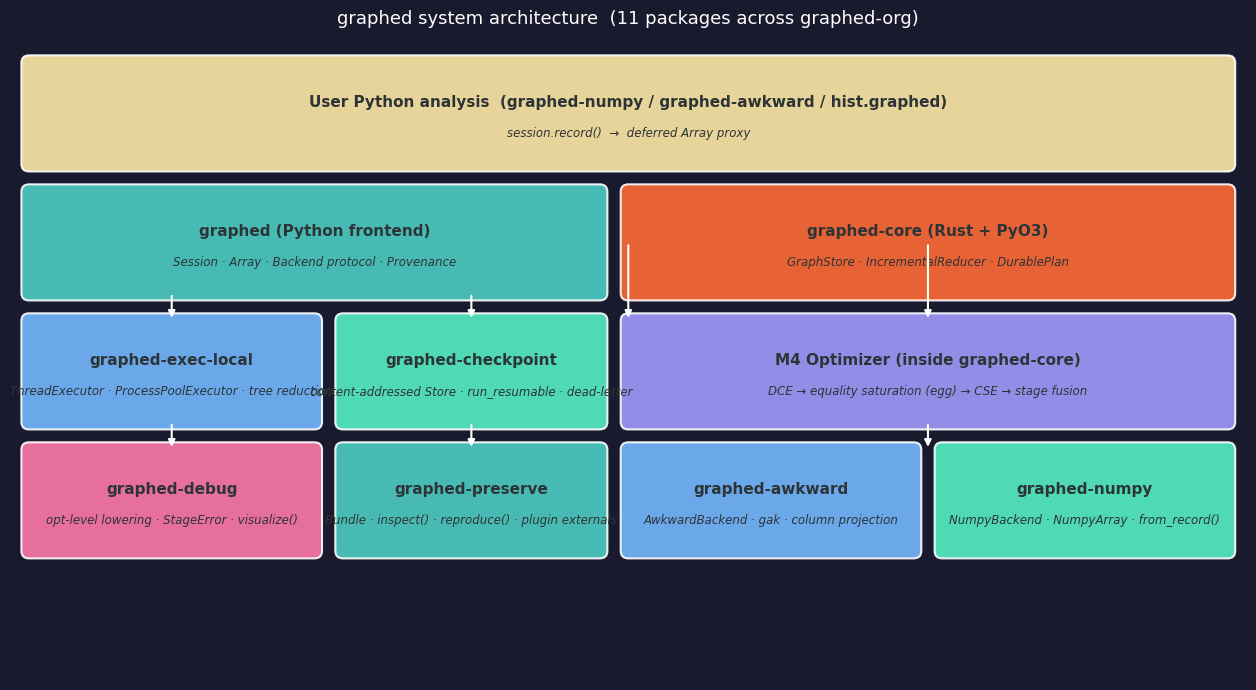

In [2]:
fig, ax = plt.subplots(figsize=(13, 7))
ax.set_xlim(0, 13); ax.set_ylim(0, 7); ax.axis("off")

TEAL = "#4ecdc4"; ORANGE = "#ff6b35"; PURPLE = "#a29bfe"
BLUE = "#74b9ff"; GREEN = "#55efc4"; YELLOW = "#ffeaa7"; RED = "#fd79a8"
DARK = "#2d3436"

def box(ax, x, y, w, h, color, label, sublabel="", fontsize=11):
    r = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
        facecolor=color, edgecolor="white", linewidth=1.5, alpha=0.9)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2+(0.12 if sublabel else 0), label, ha="center", va="center",
        color=DARK, fontsize=fontsize, fontweight="bold")
    if sublabel:
        ax.text(x+w/2, y+h/2-0.22, sublabel, ha="center", va="center",
            color=DARK, fontsize=8.5, style="italic")

def arrow(ax, x1, y1, x2, y2, color="white"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=color, lw=1.5))

# User layer
box(ax, 0.2, 5.6, 12.6, 1.1, YELLOW, "User Python analysis  (graphed-numpy / graphed-awkward / hist.graphed)", "session.record()  →  deferred Array proxy")

# Frontend
box(ax, 0.2, 4.2, 6.0, 1.1, TEAL, "graphed (Python frontend)", "Session · Array · Backend protocol · Provenance")

# Core Rust
box(ax, 6.5, 4.2, 6.3, 1.1, ORANGE, "graphed-core (Rust + PyO3)", "GraphStore · IncrementalReducer · DurablePlan")

# Optimizer
box(ax, 6.5, 2.8, 6.3, 1.1, PURPLE, "M4 Optimizer (inside graphed-core)", "DCE → equality saturation (egg) → CSE → stage fusion")

# Executor + Checkpoint
box(ax, 0.2, 2.8, 3.0, 1.1, BLUE, "graphed-exec-local", "ThreadExecutor · ProcessPoolExecutor · tree reduction")
box(ax, 3.5, 2.8, 2.7, 1.1, GREEN, "graphed-checkpoint", "content-addressed Store · run_resumable · dead-letter")

# Debug + Preserve
box(ax, 0.2, 1.4, 3.0, 1.1, RED, "graphed-debug", "opt-level lowering · StageError · visualize()")
box(ax, 3.5, 1.4, 2.7, 1.1, TEAL, "graphed-preserve", "Bundle · inspect() · reproduce() · plugin externals")

# Backends
box(ax, 6.5, 1.4, 3.0, 1.1, BLUE, "graphed-awkward", "AwkwardBackend · gak · column projection")
box(ax, 9.8, 1.4, 3.0, 1.1, GREEN, "graphed-numpy", "NumpyBackend · NumpyArray · from_record()")

# Arrows
arrow(ax, 6.5, 4.75, 6.5, 3.9)  # frontend → optimizer (via core)
arrow(ax, 9.65, 4.75, 9.65, 3.9)
arrow(ax, 1.7, 4.2, 1.7, 3.9)   # frontend → exec
arrow(ax, 4.85, 4.2, 4.85, 3.9) # frontend → checkpoint
arrow(ax, 9.65, 2.8, 9.65, 2.5) # optimizer → backends (via exec)
arrow(ax, 1.7, 2.8, 1.7, 2.5)
arrow(ax, 4.85, 2.8, 4.85, 2.5)

ax.set_title("graphed system architecture  (11 packages across graphed-org)",
    color="white", fontsize=13, pad=8)
plt.tight_layout()
plt.show()

## The Intermediate Representation

Five node kinds in `graphed-core` (Rust `NodeKey`):

```
Source    { name, params }                          ← a named input partition
Op        { name, params, inputs: [NodeId] }        ← a transformation op
Reduction { name, params, inputs: [NodeId] }        ← a boundary (e.g. sum)
External  { descriptor: PayloadDescriptor,          ← correction, ONNX model, histogram fill
            params, inputs: [NodeId] }
Stage     { members: [StageOp], inputs: [NodeId] }  ← optimizer output: fused op-DAG
```

**`External` carries a `PayloadDescriptor`:**

```python
PayloadDescriptor(
    kind="onnx_model",
    content_hash="sha256:abc123...",   # content-addressed!
    framework="onnxruntime",
    version="1.18.0",
    io_schema="float32[N,4]→float32[N]",
    preprocessing_ref=None,
)
```

→ The descriptor **participates in the structural hash** of the node
→ Two models with different content = different nodes, automatically

In [3]:
# Live demo: hash-consing — identical subexpressions share one NodeId
import sys
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
import graphed_core
from graphed import Session
# Use a minimal toy backend so this slide has no heavy deps
import sys; sys.path.insert(0,
    "/Users/lgray/vibe-coding/graphed-workdir/graphed/tests/frozen/m2")
from backends import ListBackend, from_list

s = Session(ListBackend())
a = from_list(s, "a", [1, 2, 3])
b = from_list(s, "b", [4, 5, 6])

# a + b recorded twice — should intern to ONE node
sum1 = a + b       # node id: N
sum2 = a + b       # same structural hash → same NodeId!
result = sum1 * sum2 + (a + b)  # (a+b) appears 3 times

print(f"a.node_id={a.node_id}  b.node_id={b.node_id}")
print(f"sum1.node_id={sum1.node_id}  sum2.node_id={sum2.node_id}")
print(f"sum1 is sum2 (same id)? {sum1.node_id == sum2.node_id}")
print(f"\nTotal unique nodes in store: {s.node_count()}")
print(f"  (3 ops, NOT 5 — 'a+b' is one interned node)")

a.node_id=0  b.node_id=1
sum1.node_id=2  sum2.node_id=2
sum1 is sum2 (same id)? True

Total unique nodes in store: 5
  (3 ops, NOT 5 — 'a+b' is one interned node)


### Hash-consing gives us CSE for free

```
  a ──┬──→ [add] ──→ (a+b) : NodeId #3
  b ──┘
          ↗ (already interned — returns #3)
  a ──┬──→ [add]  ← second call: same (add, [a,b]) → same id
  b ──┘
```

**Consequence:** CSE is a property of the *store*, not the optimizer.
The optimizer **asserts** it rather than deriving it.

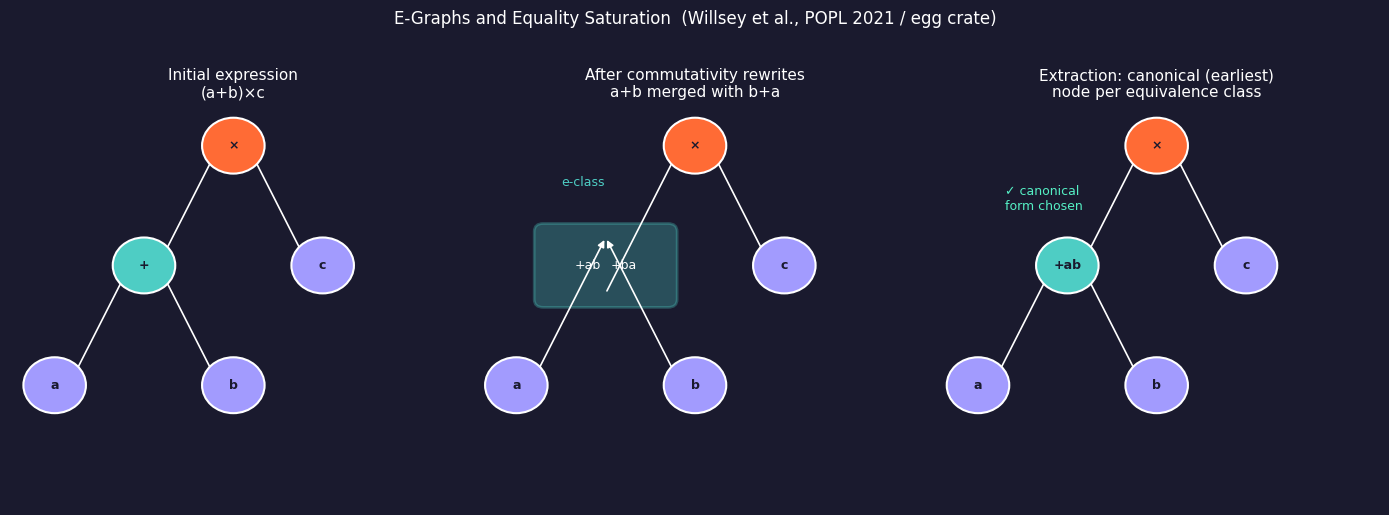

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = {"add":"#4ecdc4", "mul":"#ff6b35", "var":"#a29bfe", "lit":"#ffeaa7"}

def draw_node(ax, x, y, label, color, radius=0.35):
    c = plt.Circle((x, y), radius, color=color, zorder=3, ec="white", lw=1.5)
    ax.add_patch(c)
    ax.text(x, y, label, ha="center", va="center", fontsize=9, fontweight="bold", color="#1a1a2e", zorder=4)

def draw_edge(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2+0.35), xytext=(x1, y1-0.35),
        arrowprops=dict(arrowstyle="-|>", color="white", lw=1.2), zorder=2)

def draw_eclass(ax, x, y, labels, color, w=1.1, h=0.85):
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.1", fc=color, alpha=0.3, ec=color, lw=2, zorder=1)
    ax.add_patch(r)
    for i, lbl in enumerate(labels):
        ax.text(x + (i - (len(labels)-1)/2)*0.4, y, lbl, ha="center", va="center",
            fontsize=9, color="white", zorder=5)

for ax in axes:
    ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 4.5); ax.axis("off")

# Panel 1: initial expression  (a+b)*c
ax = axes[0]
ax.set_title("Initial expression\n(a+b)×c", color="white", fontsize=11)
draw_node(ax, 2, 4, "×", colors["mul"])
draw_node(ax, 1, 2.5, "+", colors["add"])
draw_node(ax, 3, 2.5, "c", colors["var"])
draw_node(ax, 0, 1, "a", colors["var"])
draw_node(ax, 2, 1, "b", colors["var"])
draw_edge(ax, 1, 2.5, 2, 4); draw_edge(ax, 3, 2.5, 2, 4)
draw_edge(ax, 0, 1, 1, 2.5); draw_edge(ax, 2, 1, 1, 2.5)

# Panel 2: after commutativity rule  a+b ≡ b+a
ax = axes[1]
ax.set_title("After commutativity rewrites\na+b merged with b+a", color="white", fontsize=11)
draw_eclass(ax, 1, 2.5, ["+ab", "+ba"], colors["add"], w=1.4)
draw_node(ax, 2, 4, "×", colors["mul"])
draw_node(ax, 3, 2.5, "c", colors["var"])
draw_node(ax, 0, 1, "a", colors["var"])
draw_node(ax, 2, 1, "b", colors["var"])
draw_edge(ax, 1, 2.5, 2, 4); draw_edge(ax, 3, 2.5, 2, 4)
draw_edge(ax, 0, 1, 1, 2.5); draw_edge(ax, 2, 1, 1, 2.5)
ax.text(0.5, 3.5, "e-class", color="#4ecdc4", fontsize=9)

# Panel 3: extraction — pick canonical (earliest) node per class
ax = axes[2]
ax.set_title("Extraction: canonical (earliest)\nnode per equivalence class", color="white", fontsize=11)
draw_node(ax, 2, 4, "×", colors["mul"])
draw_node(ax, 1, 2.5, "+ab", colors["add"])
draw_node(ax, 3, 2.5, "c", colors["var"])
draw_node(ax, 0, 1, "a", colors["var"])
draw_node(ax, 2, 1, "b", colors["var"])
draw_edge(ax, 1, 2.5, 2, 4); draw_edge(ax, 3, 2.5, 2, 4)
draw_edge(ax, 0, 1, 1, 2.5); draw_edge(ax, 2, 1, 1, 2.5)
ax.text(0.3, 3.2, "✓ canonical\nform chosen", color="#55efc4", fontsize=9)

plt.suptitle("E-Graphs and Equality Saturation  (Willsey et al., POPL 2021 / egg crate)",
    color="white", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## egg: Fast and Extensible Equality Saturation (POPL 2021)

> Willsey, Nandi, Wang, Flatt, Tatlock, Panchekha.
> *egg: Fast and Extensible Equality Saturation.*
> POPL 2021. https://arxiv.org/abs/2004.03082

**Key insight:** rather than applying rewrites eagerly (risking phase ordering),
build up **equivalence classes** of all reachable equivalent expressions, then extract.

**graphed uses egg for:**
- Commutativity of symmetric binary ops (`add`, `mul`, `and`, `or`, `eq`, …)
- Identity elimination (`x + 0 → x`, `x × 1 → x`)
- Sound rules only — no domain-specific rewrites in the MVP engine

**The `RewriteEngine` trait** wraps egg — no egg types leak past it.
Phase 2: swap in `egglog` without touching any other code.

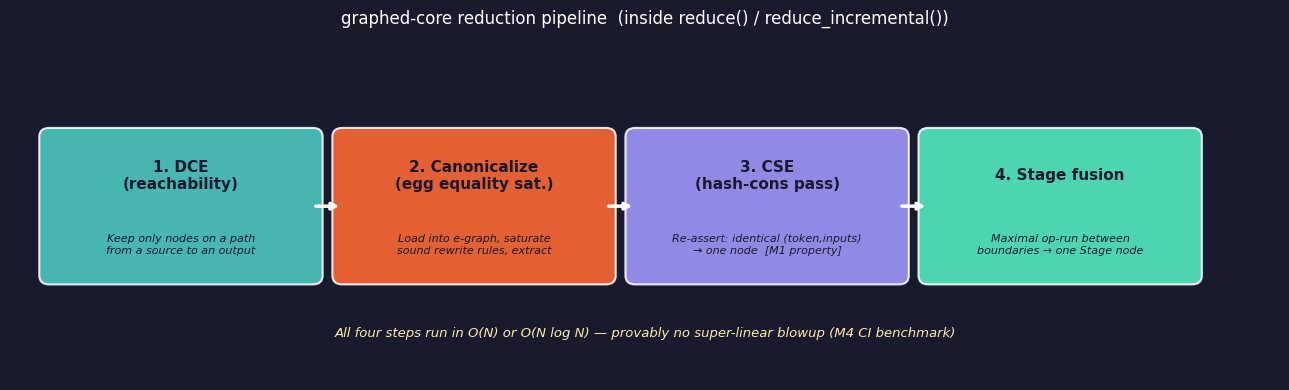

In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.set_xlim(0, 13); ax.set_ylim(0, 4); ax.axis("off")

TEAL = "#4ecdc4"; ORANGE = "#ff6b35"; PURPLE = "#a29bfe"; GREEN = "#55efc4"; YELLOW = "#ffeaa7"

steps = [
    (0.4,  "1. DCE\n(reachability)", TEAL,
     "Keep only nodes on a path\nfrom a source to an output"),
    (3.4,  "2. Canonicalize\n(egg equality sat.)", ORANGE,
     "Load into e-graph, saturate\nsound rewrite rules, extract"),
    (6.4,  "3. CSE\n(hash-cons pass)", PURPLE,
     "Re-assert: identical (token,inputs)\n→ one node  [M1 property]"),
    (9.4,  "4. Stage fusion", GREEN,
     "Maximal op-run between\nboundaries → one Stage node"),
]

for x, title, color, desc in steps:
    r = mpatches.FancyBboxPatch((x, 1.2), 2.7, 1.6, boxstyle="round,pad=0.1",
        facecolor=color, edgecolor="white", lw=1.5, alpha=0.88)
    ax.add_patch(r)
    ax.text(x+1.35, 2.35, title, ha="center", va="center", fontsize=11,
        fontweight="bold", color="#1a1a2e")
    ax.text(x+1.35, 1.55, desc, ha="center", va="center", fontsize=8,
        color="#1a1a2e", style="italic")

for xi in [3.1, 6.1, 9.1]:
    ax.annotate("", xy=(xi+0.3, 2.0), xytext=(xi, 2.0),
        arrowprops=dict(arrowstyle="-|>", color="white", lw=2.5))

ax.text(6.5, 0.5, "All four steps run in O(N) or O(N log N) — provably no super-linear blowup (M4 CI benchmark)",
    ha="center", fontsize=9.5, color=YELLOW, style="italic")
ax.set_title("graphed-core reduction pipeline  (inside reduce() / reduce_incremental())",
    color="white", fontsize=12, pad=6)
plt.tight_layout()
plt.show()

In [6]:
# Measure: what does reduction actually do to a graph?
import sys
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed/tests/frozen/m2")
import graphed_core
from graphed import Session
from backends import ListBackend, from_list

# Build a graph with repeated sub-expressions and dead branches
s = Session(ListBackend())
a = from_list(s, "a", [1.0, 2.0, 3.0])
b = from_list(s, "b", [4.0, 5.0, 6.0])

# Symmetric duplicates: a+b and b+a should merge
s1 = a + b
s2 = b + a          # commutativity → same canonical form
dead = (a + b) * b  # dead branch: not an output
result = s1 + s2 + (a + b)  # (a+b) three times → still ONE interned node

print(f"Before reduction: {s.node_count()} nodes")
report = s._store.reduction_report(outputs=[result.node_id])
print(f"Reduction report: {report}")

reduced, remap = s._store.reduce(outputs=[result.node_id])
print(f"After  reduction: {reduced.node_count()} nodes (dead branch + duplicates removed)")

Before reduction: 7 nodes
Reduction report: {'reachable_nodes': 6, 'input_nodes': 7, 'canonical_nodes': 5, 'stages': 2, 'reduced_nodes': 4, 'boundary_nodes': 2}
After  reduction: 4 nodes (dead branch + duplicates removed)


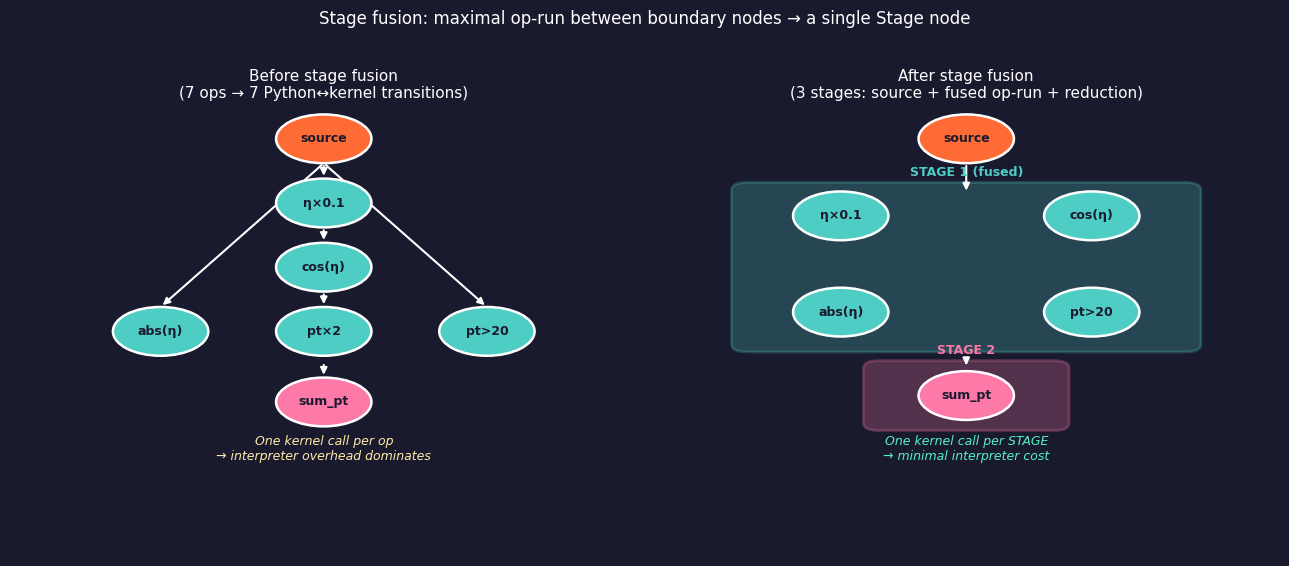

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
TEAL="#4ecdc4"; ORANGE="#ff6b35"; RED="#fd79a8"; PURPLE="#a29bfe"; GREEN="#55efc4"

def draw_gnode(ax, x, y, label, color, r=0.38):
    c = plt.Circle((x, y), r, color=color, zorder=3, ec="white", lw=1.8)
    ax.add_patch(c)
    ax.text(x, y, label, ha="center", va="center", fontsize=9, fontweight="bold",
        color="#1a1a2e", zorder=4)

def draw_gedge(ax, x1, y1, x2, y2, style="-|>", color="white"):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle=style, color=color, lw=1.5), zorder=2)

def draw_stage_box(ax, x, y, w, h, label, color):
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.12", fc=color, alpha=0.25, ec=color, lw=2, zorder=1)
    ax.add_patch(r)
    ax.text(x, y+h/2+0.18, label, ha="center", va="bottom", fontsize=9,
        color=color, fontweight="bold")

# Left panel: before fusion (7 separate ops = 7 Python→kernel transitions)
ax = axes[0]
ax.set_xlim(0, 5); ax.set_ylim(0, 7); ax.axis("off")
ax.set_title("Before stage fusion\n(7 ops → 7 Python↔kernel transitions)", color="white", fontsize=11)

# source (boundary)
draw_gnode(ax, 2.5, 6.5, "source", ORANGE)
# op chain
for i, (lbl, yi) in enumerate([("η×0.1", 5.5), ("cos(η)", 4.5), ("pt×2", 3.5), ("sum_pt", 2.4)]):
    color = RED if lbl == "sum_pt" else TEAL
    draw_gnode(ax, 2.5, yi, lbl, color)
    draw_gedge(ax, 2.5, yi+1-0.38, 2.5, yi+0.38)

# second branch
draw_gnode(ax, 1.2, 3.5, "abs(η)", TEAL)
draw_gnode(ax, 3.8, 3.5, "pt>20", TEAL)
draw_gedge(ax, 2.5, 6.5-0.38, 1.2, 3.5+0.38)
draw_gedge(ax, 2.5, 6.5-0.38, 3.8, 3.5+0.38)

ax.text(2.5, 1.5, "One kernel call per op\n→ interpreter overhead dominates",
    ha="center", color="#ffeaa7", fontsize=9, style="italic")

# Right panel: after fusion (3 stages)
ax = axes[1]
ax.set_xlim(0, 5); ax.set_ylim(0, 7); ax.axis("off")
ax.set_title("After stage fusion\n(3 stages: source + fused op-run + reduction)", color="white", fontsize=11)

draw_gnode(ax, 2.5, 6.5, "source", ORANGE)

draw_stage_box(ax, 2.5, 4.5, 3.5, 2.4, "STAGE 1 (fused)", TEAL)
draw_gnode(ax, 1.5, 5.3, "η×0.1", TEAL)
draw_gnode(ax, 3.5, 5.3, "cos(η)", TEAL)
draw_gnode(ax, 1.5, 3.8, "abs(η)", TEAL)
draw_gnode(ax, 3.5, 3.8, "pt>20", TEAL)

draw_stage_box(ax, 2.5, 2.5, 1.4, 0.85, "STAGE 2", RED)
draw_gnode(ax, 2.5, 2.5, "sum_pt", RED)

draw_gedge(ax, 2.5, 6.5-0.38, 2.5, 5.65)  # src → stage1
draw_gedge(ax, 2.5, 3.08, 2.5, 2.93)       # stage1 → stage2

ax.text(2.5, 1.5, "One kernel call per STAGE\n→ minimal interpreter cost",
    ha="center", color="#55efc4", fontsize=9, style="italic")

plt.suptitle("Stage fusion: maximal op-run between boundary nodes → a single Stage node",
    color="white", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# The deferred proxy: recording an analysis
import sys
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed-numpy/src")
import numpy as np
from graphed import Session
from graphed_numpy import NumpyBackend, from_array

# Build a Session with the numpy backend
s = Session(NumpyBackend())

# from_array records a Source node; returns a deferred Array proxy
events_pt  = from_array(s, "pt",  np.array([30., 25., 80., 12., 60.]))
events_eta = from_array(s, "eta", np.array([0.2, 1.1, -0.5, 2.0, -1.3]))

# All arithmetic is DEFERRED — no computation happens here
pt_cut  = events_pt > 25.0        # records an Op node
eta_cut = np.abs(events_eta) < 1.5
selected = events_pt[pt_cut & eta_cut]  # records filter + field-access ops
total_pt = selected.sum()          # records a Reduction node (boundary)

print(f"Type of 'selected': {type(selected).__name__}  (a deferred Array proxy)")
print(f"Type of 'total_pt': {type(total_pt).__name__}  (a deferred Array proxy)")
print(f"Nodes recorded in the graph: {s.node_count()}")
print()

# Provenance: every op knows where in user code it was recorded
from graphed import capture
prov = s.provenance(total_pt)
print(f"Provenance of total_pt: {prov}")

Type of 'selected': NumpyArray  (a deferred Array proxy)
Type of 'total_pt': NumpyArray  (a deferred Array proxy)
Nodes recorded in the graph: 8

Provenance of total_pt: /var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/3359819623.py:20


### The Session contract

| Concern | Where it lives |
|---|---|
| **Graph storage** | `GraphStore` in Rust (thread-safe, interning) |
| **Forms** (shapes/types) | Backend's `op_form()` call, stored in Session |
| **Provenance** | Python frame captured at `record_*` time |
| **Incremental reduction** | Optional `IncrementalReducer` stepped at each record |
| **Evaluation** | Backend's `eval_stage()` — never called during recording |

The Session owns **no backend-specific types**.
The backend owns **no IR-specific types**.
→ They meet only at `op_form()` (recording) and `eval_stage()` (execution).

## Data Model: What Are the First-Class Citizens?

**Question:** like dask (data types first), or function-centric?

### User API level: Arrays are first-class (like dask.Array)
```python
events_pt  = from_array(session, "pt", ...)   # → deferred Array proxy
result     = (events_pt[events_pt > 25]).sum() # → another deferred Array proxy
```
Arrays are the programming model. The user never sees nodes or edges.

### IR level: the graph is a **functional DAG** (nodes are ops, not data)

```
NodeId 0: Source("pt")                 ← data entry point
NodeId 1: Source("eta")
NodeId 2: Op("gt", inputs=[0], params={scalar: 25.0})   ← function, not data
NodeId 3: Op("filter", inputs=[0, 2])
NodeId 4: Reduction("sum", inputs=[3]) ← boundary: reduces to a scalar
```

**Data never lives in the IR.** Only:
- Source names (resolved to actual data at execution time, per partition)
- Type/shape information (Forms, stored beside the IR in the Session)
- Node connectivity (who feeds whom)

**Key difference from dask:** graphed separates the *recorded computation* (IR, pure structure)
from the *type metadata* (Forms, backend-dependent) from the *actual data* (loaded per partition).

## Backend Protocol and the Typetracer

**Backend protocol (Python `Protocol`):**

```python
class Backend(Protocol):
    def source_form(self, name: str, data: object) -> Form: ...
    def op_form(self, op: str, inputs: Sequence[Form],
                params: Mapping[str, ParamValue]) -> Form: ...
    def eval_stage(self, ops: list[OpSpec],
                   inputs: dict[str, object]) -> object: ...
    def boundary_ops(self) -> frozenset[str]: ...
```

**Key insight:** `op_form` uses the **awkward typetracer**
— a pure metadata evaluation with no event data.

```python
# Inside AwkwardBackend.op_form("add", [form_a, form_b], {}):
#   creates a typetracer array from form_a's type descriptor
#   runs: typetracer_a + typetracer_b
#   returns: AwkwardForm(type_str=str(result.type))
#   ↑ zero actual data ever read
```

**graphed-numpy** uses zero-length meta arrays for the same purpose.
**Reuse, don't reinvent** — awkward already solved type inference for HEP arrays.

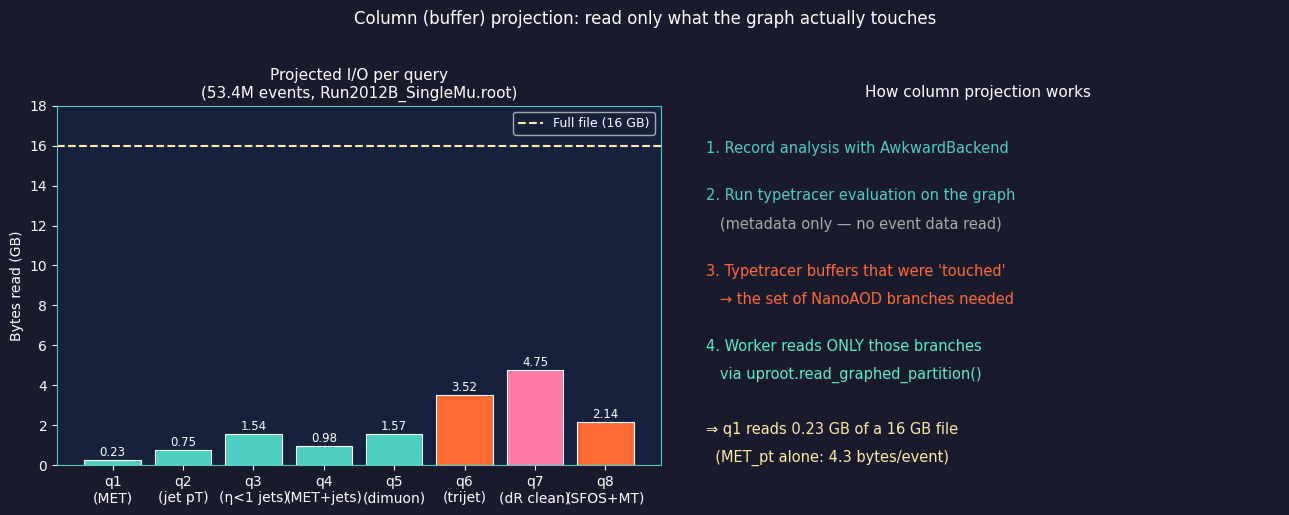

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

queries = ["q1\n(MET)", "q2\n(jet pT)", "q3\n(η<1 jets)", "q4\n(MET+jets)",
           "q5\n(dimuon)", "q6\n(trijet)", "q7\n(dR clean)", "q8\n(SFOS+MT)"]
bytes_gb = [0.23, 0.75, 1.54, 0.98, 1.57, 3.52, 4.75, 2.14]
n_branches = [1, 4, 6, 5, 5, 7, 11, 8]  # approximate projected branch count

colors_proj = ["#4ecdc4" if b < 2 else "#ff6b35" if b < 4 else "#fd79a8" for b in bytes_gb]

bars = ax1.bar(queries, bytes_gb, color=colors_proj, edgecolor="white", linewidth=0.8)
ax1.axhline(16.0, color="#ffeaa7", linestyle="--", lw=1.5, label="Full file (16 GB)")
ax1.set_ylabel("Bytes read (GB)", fontsize=10)
ax1.set_title("Projected I/O per query\n(53.4M events, Run2012B_SingleMu.root)", fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 18)
for bar, gb in zip(bars, bytes_gb):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f"{gb:.2f}",
        ha="center", fontsize=8.5, color="white")

# Panel 2: explain how projection works
ax2.axis("off")
ax2.set_title("How column projection works", fontsize=11)
steps_text = [
    ("1. Record analysis with AwkwardBackend", 0.88, "#4ecdc4"),
    ("2. Run typetracer evaluation on the graph", 0.75, "#4ecdc4"),
    ("   (metadata only — no event data read)", 0.67, "#aaaaaa"),
    ("3. Typetracer buffers that were 'touched'", 0.54, "#ff6b35"),
    ("   → the set of NanoAOD branches needed", 0.46, "#ff6b35"),
    ("4. Worker reads ONLY those branches", 0.33, "#55efc4"),
    ("   via uproot.read_graphed_partition()", 0.25, "#55efc4"),
    ("⇒ q1 reads 0.23 GB of a 16 GB file", 0.10, "#ffeaa7"),
    ("  (MET_pt alone: 4.3 bytes/event)", 0.02, "#ffeaa7"),
]
for text, y, color in steps_text:
    ax2.text(0.05, y, text, transform=ax2.transAxes,
        fontsize=10.5, color=color, va="center")

plt.suptitle("Column (buffer) projection: read only what the graph actually touches",
    color="white", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## The Execution Contract

**`Plan` (in `graphed_core`):**
```python
@dataclass
class Plan(Generic[R]):
    tasks:      tuple[Task, ...]         # fixed partition list
    process:    Callable[[Partition], R] # worker function: one partition → partial
    combine:    Callable[[R, R], R]      # associative combiner
    empty:      Callable[[], R]          # identity element for combine
    open_once:  Callable[[str], object]  # file-locality: uri opened once per worker
    stop:       StopCondition | None     # optional early stopping
    next_tasks: ...                      # optional adaptive reshaping
```

**Properties that enable correctness:**
- `combine` is **associative** → tree reduction is safe
- `combine(empty(), x) == x` → partial results compose cleanly
- `process` is **pure** (same partition → same partial) → checkpointing works

**Two executor flavors:**
- `ThreadExecutor` — shared memory, GIL-free 3.14t
- `ProcessPoolExecutor` / `PinnedPoolExecutor` — process isolation, full parallelism

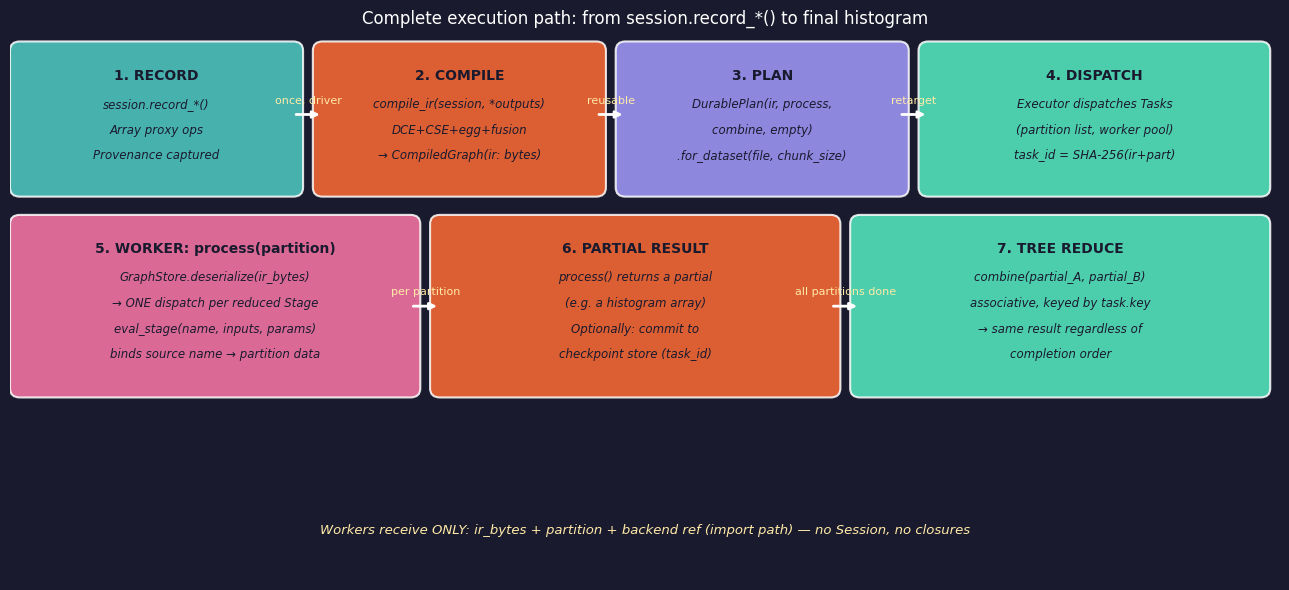

In [10]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 13); ax.set_ylim(0, 6); ax.axis("off")
TEAL="#4ecdc4"; ORANGE="#ff6b35"; PURPLE="#a29bfe"; GREEN="#55efc4"; YELLOW="#ffeaa7"; RED="#fd79a8"

def step_box(ax, x, y, w, h, title, body, color):
    r = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1",
        facecolor=color, alpha=0.85, edgecolor="white", lw=1.5)
    ax.add_patch(r)
    ax.text(x+w/2, y+h-0.2, title, ha="center", va="top", fontsize=10,
        fontweight="bold", color="#1a1a2e")
    for i, line in enumerate(body.split("\n")):
        ax.text(x+w/2, y+h-0.52-i*0.28, line, ha="center", va="top",
            fontsize=8.5, color="#1a1a2e", style="italic")

def harrow(ax, x1, x2, y, label=""):
    ax.annotate("", xy=(x2, y), xytext=(x1, y),
        arrowprops=dict(arrowstyle="-|>", color="white", lw=2))
    if label:
        ax.text((x1+x2)/2, y+0.12, label, ha="center", fontsize=8, color=YELLOW)

# Row 1: recording phase
step_box(ax, 0.1, 4.3, 2.8, 1.5, "1. RECORD",
    "session.record_*()\nArray proxy ops\nProvenance captured", TEAL)
step_box(ax, 3.2, 4.3, 2.8, 1.5, "2. COMPILE",
    "compile_ir(session, *outputs)\nDCE+CSE+egg+fusion\n→ CompiledGraph(ir: bytes)", ORANGE)
step_box(ax, 6.3, 4.3, 2.8, 1.5, "3. PLAN",
    "DurablePlan(ir, process,\ncombine, empty)\n.for_dataset(file, chunk_size)", PURPLE)
step_box(ax, 9.4, 4.3, 3.4, 1.5, "4. DISPATCH",
    "Executor dispatches Tasks\n(partition list, worker pool)\ntask_id = SHA-256(ir+part)", GREEN)

harrow(ax, 2.9, 3.2, 5.1, "once, driver")
harrow(ax, 6.0, 6.3, 5.1, "reusable")
harrow(ax, 9.1, 9.4, 5.1, "retarget")

# Row 2: worker phase
step_box(ax, 0.1, 2.1, 4.0, 1.8, "5. WORKER: process(partition)",
    "GraphStore.deserialize(ir_bytes)\n→ ONE dispatch per reduced Stage\neval_stage(name, inputs, params)\nbinds source name → partition data", RED)
step_box(ax, 4.4, 2.1, 4.0, 1.8, "6. PARTIAL RESULT",
    "process() returns a partial\n(e.g. a histogram array)\nOptionally: commit to\ncheckpoint store (task_id)", ORANGE)
step_box(ax, 8.7, 2.1, 4.1, 1.8, "7. TREE REDUCE",
    "combine(partial_A, partial_B)\nassociative, keyed by task.key\n→ same result regardless of\ncompletion order", GREEN)

harrow(ax, 4.1, 4.4, 3.0, "per partition")
harrow(ax, 8.4, 8.7, 3.0, "all partitions done")

# Key annotation
annot = "Workers receive ONLY: ir_bytes + partition + backend ref (import path) — no Session, no closures"
ax.text(6.5, 0.5, annot, ha="center", fontsize=9.5, color=YELLOW, style="italic")

ax.set_title("Complete execution path: from session.record_*() to final histogram",
    color="white", fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# Concrete: what does evaluate_ir (the worker kernel) actually do?
print('''
def evaluate_ir(compiled: CompiledGraph, backend: Backend,
                sources: Mapping[str, object],
                externals: Mapping[str, Callable] | None = None) -> list[object]:

    store = GraphStore.deserialize(compiled.ir)   # ← deserialize once per worker
    vals = []
    for nd in store.nodes():                      # ← topological order
        kind = nd["kind"]
        ins  = [vals[i] for i in nd["inputs"]]    # ← resolved from earlier nodes

        if kind == "source":
            vals.append(sources[nd["name"]])       # ← partition data bound by name

        elif kind in ("op", "reduction"):          # ← single op: one backend call
            vals.append(backend.eval_stage(nd["name"], ins, nd["params"]))

        elif kind == "stage":                      # ← FUSED op-run: inline loop
            mvals = []
            for m in nd["members"]:               # ← each fused member
                mins = [ins[i] if tag=="input" else mvals[i]
                        for tag, i in m["inputs"]]
                mvals.append(backend.eval_stage(m["name"], mins, m["params"]))
            vals.append(mvals[-1])                # ← stage output = last member

        elif kind == "external":
            chash = nd["descriptor"]["content_hash"]
            vals.append(externals[chash](*ins))   # ← resolved by content hash

    return [vals[o] for o in store.outputs()]
''')
print("Key property: ONE backend.eval_stage() call per STAGE (not per original op)")
print("Stage fusion reduces interpreter overhead proportionally to the fusion ratio")


def evaluate_ir(compiled: CompiledGraph, backend: Backend,
                sources: Mapping[str, object],
                externals: Mapping[str, Callable] | None = None) -> list[object]:

    store = GraphStore.deserialize(compiled.ir)   # ← deserialize once per worker
    vals = []
    for nd in store.nodes():                      # ← topological order
        kind = nd["kind"]
        ins  = [vals[i] for i in nd["inputs"]]    # ← resolved from earlier nodes

        if kind == "source":
            vals.append(sources[nd["name"]])       # ← partition data bound by name

        elif kind in ("op", "reduction"):          # ← single op: one backend call
            vals.append(backend.eval_stage(nd["name"], ins, nd["params"]))

        elif kind == "stage":                      # ← FUSED op-run: inline loop
            mvals = []
            for m in nd["members"]:               # ← each fused member
                mins = [ins[i] if tag=="input" else mvals[i]
                       

## Static Graph, Dynamic Partitions

**Does the complete graph have to be defined from the beginning?**

### The IR (computation graph): YES, fully static at compile time
```
session.record_*()  →  compile_ir()  →  ir_bytes  ← frozen here
```
Once serialized, the computation graph is immutable.
Workers deserialized it for every partition. **No graph growth during execution.**

### The partition list: can be DYNAMIC (adaptive reshaping)

```python
@dataclass
class Plan:
    tasks:      tuple[Task, ...]   # fixed partition list — OR:
    next_tasks: Callable[[ExecContext], Sequence[Task] | None]  # adaptive!
    # next_tasks is called after each completion with the running ExecContext
    # (n_done, events_done, elapsed_s, errors) → return None to stop
```

**Use cases for dynamic partitions:**
- `StopCondition.target_events`: stop after N events (statistical precision target)
- `StopCondition.max_wall_s`: stop after a time budget (online monitoring)
- Adaptive chunk sizing: smaller chunks if workers are OOM (Phase 2)

**Incremental reduction goes further:** the IR itself is canonicalized as each op is added,
so you can **record incrementally** (each `session.record_*()` immediately steps the
IncrementalReducer) — but the IR snapshot at any point is a well-defined, fully reducible graph.
It is not discovered lazily; it is built up with incremental optimization.

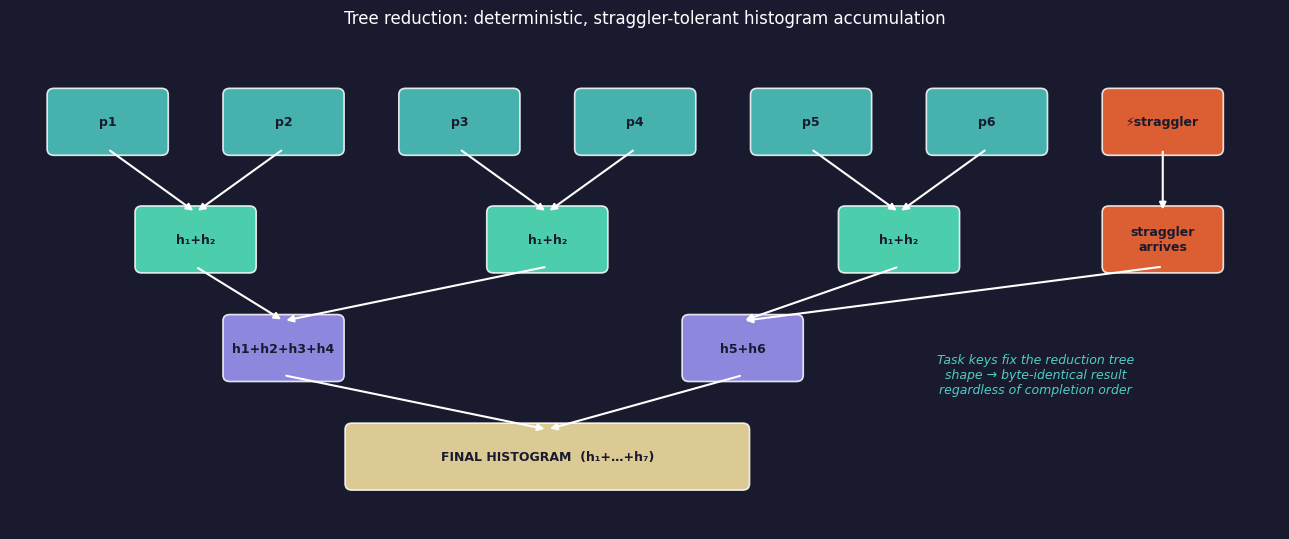

In [12]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_xlim(0, 13); ax.set_ylim(0, 5.5); ax.axis("off")
ax.set_title("Tree reduction: deterministic, straggler-tolerant histogram accumulation",
    color="white", fontsize=12)

TEAL="#4ecdc4"; ORANGE="#ff6b35"; GREEN="#55efc4"; PURPLE="#a29bfe"; YELLOW="#ffeaa7"

def pbox(ax, x, y, label, color, w=1.1, h=0.6):
    r = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.07", facecolor=color, alpha=0.85, edgecolor="white", lw=1.2)
    ax.add_patch(r)
    ax.text(x, y, label, ha="center", va="center", fontsize=9, color="#1a1a2e", fontweight="bold")

def parrow(ax, x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2+0.3), xytext=(x1, y1-0.3),
        arrowprops=dict(arrowstyle="-|>", color="white", lw=1.5))

# Leaf partitions (workers)
xs = [1.0, 2.8, 4.6, 6.4, 8.2, 10.0, 11.8]
for i, x in enumerate(xs):
    label = f"p{i+1}" if i < 6 else "⚡straggler"
    color = TEAL if i < 6 else ORANGE
    pbox(ax, x, 4.5, label, color)

# Level 1 reduces
pairs = [(1.0, 2.8), (4.6, 6.4), (8.2, 10.0)]
mid_xs_l1 = [(a+b)/2 for a,b in pairs]
for x in mid_xs_l1:
    pbox(ax, x, 3.2, "h₁+h₂", GREEN)

# Level 1 → Level 2 arrows
for (x1,x2), mx in zip(pairs, mid_xs_l1):
    parrow(ax, x1, 4.5, mx, 3.2)
    parrow(ax, x2, 4.5, mx, 3.2)

# straggler feeds in at level 1 when ready
pbox(ax, 11.8, 3.2, "straggler\narrives", ORANGE)
parrow(ax, 11.8, 4.5, 11.8, 3.2)

# Level 2
l2_xs = [mid_xs_l1[0], mid_xs_l1[1]]
pbox(ax, 2.8, 2.0, "h1+h2+h3+h4", PURPLE)
pbox(ax, 7.5, 2.0, "h5+h6", PURPLE)
parrow(ax, mid_xs_l1[0], 3.2, 2.8, 2.0)
parrow(ax, mid_xs_l1[1], 3.2, 2.8, 2.0)
parrow(ax, mid_xs_l1[2], 3.2, 7.5, 2.0)
parrow(ax, 11.8, 3.2, 7.5, 2.0)

# Final
pbox(ax, 5.5, 0.8, "FINAL HISTOGRAM  (h₁+…+h₇)", YELLOW, w=4.0)
parrow(ax, 2.8, 2.0, 5.5, 0.8)
parrow(ax, 7.5, 2.0, 5.5, 0.8)

ax.text(10.5, 1.5, "Task keys fix the reduction tree\nshape → byte-identical result\nregardless of completion order",
    color=TEAL, fontsize=9, style="italic", ha="center")
plt.tight_layout()
plt.show()

## Checkpointing: Content-Addressed Store

**The key insight: a task's identity is its IR + partition + process spec**

```python
task_id = SHA-256(
    canonical_ir_bytes        # the optimized, serialized graph — not cloudpickle
    + process_spec_bytes      # the compiled analysis function reference
    + partition_bytes         # (uri, tree, entry_start, entry_stop)
)
```

**`run_resumable()` algorithm:**

```
for partition in plan.tasks:
    if store.has(task_id(partition)):
        partial = store.load(task_id(partition))   # SKIP — reuse stored result
        report.skipped += 1
    else:
        partial = process(partition)               # RUN the expensive computation
        store.commit(task_id(partition), partial)  # persist atomically
        report.executed += 1

result = tree_reduce(plan.combine, all_partials_in_task_key_order)
```

**Correctness guarantees:**
- No double-count: each partition contributes exactly once
- No lost partition: reduction always uses all stored partials
- Bit-for-bit equal to uninterrupted run: same associative reduction, same order

In [13]:
# Checkpoint demo: content-addressed task IDs from a DurablePlan
import sys, tempfile, pathlib
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed/tests/frozen/m2")
import graphed_core
from graphed import Session
from graphed_checkpoint import Store
from backends import ListBackend, from_list

# Build a tiny plan to show how task IDs work
s = Session(ListBackend())
a = from_list(s, "data", [1.0, 2.0, 3.0])
result = a + a
ir_bytes = s.serialized_ir(result)

plan = graphed_core.DurablePlan(
    ir=ir_bytes,
    process=graphed_core.OpSpec.from_ref("builtins:list"),
    combine=graphed_core.OpSpec.from_ref("operator:add"),
    empty=graphed_core.OpSpec.from_ref("builtins:list"),
)
p1 = graphed_core.Partition("file://a.root", "Events", 0, 1000)
p2 = graphed_core.Partition("file://a.root", "Events", 1000, 2000)
plan_p = plan.with_partitions((p1, p2))

print("task_id for partition 1:", plan_p.task_id(p1)[:16], "...")
print("task_id for partition 2:", plan_p.task_id(p2)[:16], "...")
print()
print("Same IR + different partitions → different task IDs (content-addressed)")
print("Same IR + same partition → identical task ID across machines (deterministic)")
print()
print("On crash and resume:")
print("  - task_id already in store → skip process(), reuse stored partial")
print("  - task_id NOT in store → run process(), commit result atomically")
print("  - Final reduce: ALL task partials in deterministic key order → bit-for-bit result")

task_id for partition 1: 2c84248bcba476c3 ...
task_id for partition 2: 4228d1ad4b142c86 ...

Same IR + different partitions → different task IDs (content-addressed)
Same IR + same partition → identical task ID across machines (deterministic)

On crash and resume:
  - task_id already in store → skip process(), reuse stored partial
  - task_id NOT in store → run process(), commit result atomically
  - Final reduce: ALL task partials in deterministic key order → bit-for-bit result


In [14]:
import sys
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed-numpy/src")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed-debug/src")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed/src")

import numpy as np
import graphed_numpy as gn
import graphed_debug as gd
from graphed import Session

# An analysis with a deliberate out-of-range index (simulating a broken analysis)
s = Session(gn.NumpyBackend())
events = gn.from_record(s, "events", pt=np.arange(1.0, 4.0), eta=np.linspace(0, 1, 3))
scaled = events["pt"] * 2.0
bad = scaled.map(lambda a: a[100], name="oob_index")   # <── the failing analysis line

# Run — StageError carries the user source frame (this is what a remote worker would surface)
try:
    gd.run(s, bad, opt_level=1)
except gd.StageError as err:
    print("StageError caught — format_traceback maps it to the user's line:")
    print()
    print(gd.format_traceback(err))
    print()
    print(f"Failing op: {err.op}")
    print(f"Source file: {err.user_frame.filename.split('/')[-1]}:{err.user_frame.lineno}")
    print(f"Expression:  {err.user_frame.source!r}")
    print()
    # Verify picklability (key for process-boundary transport)
    import pickle
    blob = pickle.dumps(err)
    print(f"Pickled StageError size: {len(blob)} bytes  (survives process boundary intact)")

StageError caught — format_traceback maps it to the user's line:

Traceback (most recent call last) — user analysis frames:
      File "/var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/3663645655.py", line 14, in <module>
          gn.from_record(s, 'events', pt=np.arange(1.0, 4.0), eta=np.linspace(0, 1, 3))
      File "/var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/3663645655.py", line 15, in <module>
          events['pt']
      File "/var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/3663645655.py", line 15, in <module>
          events['pt'] * 2.0
  --> File "/var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/3663645655.py", line 16, in <module>
          scaled.map(lambda a: a[100], name='oob_index')
IndexError: index 100 is out of bounds for axis 0 with size 3  [stage op 'external', partition sample, opt_level=1]
  input forms: vector[float64]

Failing op: external
Source file: 3663645655.py:16
Expression:  "scaled.map(lam

## Source-Mapped Tracebacks — Why It Matters

**The problem (dask failure #8):**
A runtime error deep inside a fused kernel on a remote worker → opaque
`"WorkerLost: exception RuntimeError in worker …"` → no user source line

**graphed's guarantee:**
- `StageError` is a plain-data picklable exception
- It carries the user's source file, line number, and expression text
- It survives a process boundary **intact** — `__reduce__` / `__setstate__`
- `format_traceback(err)` collapses `graphed*` frames and marks the failing line

**`opt_level=0` vs `opt_level=1`:**
- `opt_level=0`: every op is its own stage → can localize which op failed within a fused kernel
- `opt_level=1`: maximal fusion → matches actual execution; error still maps to the user's line

Both point to the **same source location**.

In [15]:
import sys
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed-numpy/src")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed-debug/src")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed/src")

import numpy as np
from graphed import Session
import graphed_numpy as gn
import graphed_debug as gd

s = Session(gn.NumpyBackend())
ev = gn.from_record(s, "events", pt=np.arange(5.0), eta=np.arange(5.0), phi=np.arange(5.0))

# A small HEP-flavoured analysis: pT-weighted mean η of high-pT jets
pt   = ev["pt"]
eta  = ev["eta"]
mask = pt > 25.0
sel_pt  = pt[mask]
sel_eta = eta[mask]
result = (sel_pt * sel_eta).sum()

lowered = gd.lower(s, result, opt_level=1)
print("Mermaid diagram of the stage graph:")
print()
mermaid_src = gd.visualize(lowered, fmt="mermaid")
print(mermaid_src)
print()
print(f"Stages: {len(lowered.stages)}")
print(f"(Fused from {s.node_count()} original nodes into {len(lowered.stages)} stages)")

Mermaid diagram of the stage graph:

flowchart TD  %% opt_level=1
  n0["source events\n@ /var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/1463798885.py:13"]
  n1["stage[field]\n@ /var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/1463798885.py:16"]
  n3["stage[gt]\n@ /var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/1463798885.py:18"]
  n6["stage[getitem → field → getitem → mul]\n@ /var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/1463798885.py:21"]
  n7["boundary[sum]\n@ /var/folders/_8/wdyynsx91n91t7x7xwn69bsc0000gn/T/ipykernel_9198/1463798885.py:21"]
  n0 --> n1
  n1 --> n3
  n0 --> n6
  n1 --> n6
  n3 --> n6
  n6 --> n7

Stages: 5
(Fused from 8 original nodes into 5 stages)


## Analysis Preservation Bundle

**Goal:** reproduce histograms bit-for-bit on a clean machine with NO access to:
- the original user code
- the original environment
- the original input files

**Bundle contents:**
```
bundle/
├── manifest.json       # content-addressed, versioned
├── ir.bin              # canonical serialized IR (not cloudpickle)
├── partitions.json     # partition list with content hashes
└── payloads/
    ├── sha256:abc123.onnx        # ONNX model, by content hash
    ├── sha256:def456.json        # correctionlib correction
    └── sha256:ghi789.npz        # histogram (UHI)
```

**Plugin system for externals:**
`ONNX`, `correctionlib`, `boost_histogram`, `PyTorch`, `TensorFlow`, `JAX`, `XGBoost`, `Triton`

```python
bundle = build_bundle(plan, store)
# On a clean machine:
hists = reproduce(bundle)          # runs entirely from the bundle
info  = inspect(bundle)            # describes inputs/outputs without executing
```

## ADL Benchmark Suite (8 queries)

The Analysis Description Language benchmarks from the coffea paper:

| Query | Description | Key challenge |
|---|---|---|
| **q1** | MET distribution | trivial, single branch |
| **q2** | Jet pT distribution | ragged per-event jets |
| **q3** | Jet pT, \|η\| < 1 | filtering on ragged |
| **q4** | MET with ≥ 2 jets | event-level selection |
| **q5** | Dimuon invariant mass | two-body combinations |
| **q6** | Trijet + closest-to-172 GeV | C(n,3) combinatorics, heaviest query |
| **q7** | Jet pT sum (dR-cleaned from muons) | cross-collection ΔR matching |
| **q8** | SFOS dimuon + MT | same-flavor opposite-sign pairs |

**Key properties:**
- Each query = ONE compiled graph, re-targeted at ~100 partitions
- All 8 queries bit-for-bit match coffea on the 50k acceptance skim
- Column projection is automatic — no user annotation needed

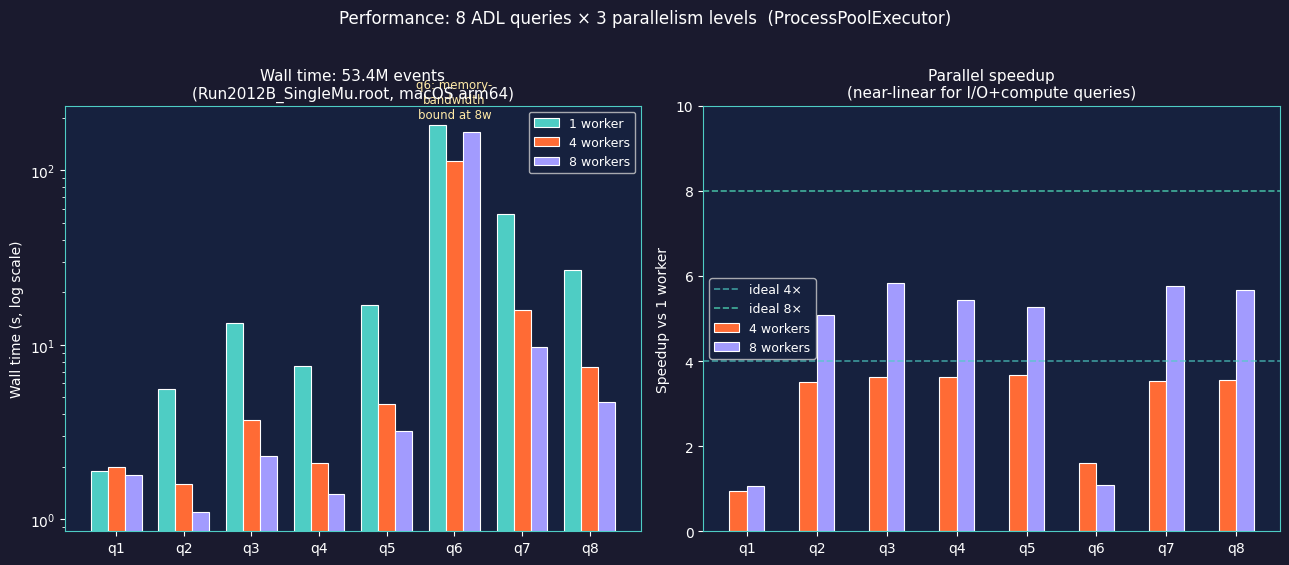

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

queries = ["q1", "q2", "q3", "q4", "q5", "q6", "q7", "q8"]
t1 = [1.9, 5.6, 13.4, 7.6, 16.9, 181.9, 56.0, 26.7]
t4 = [2.0, 1.6,  3.7, 2.1,  4.6, 112.9, 15.9,  7.5]
t8 = [1.8, 1.1,  2.3, 1.4,  3.2, 166.6,  9.7,  4.7]
bytes_gb = [0.23, 0.75, 1.54, 0.98, 1.57, 3.52, 4.75, 2.14]

x = np.arange(len(queries))
w = 0.25

ax = axes[0]
b1 = ax.bar(x-w, t1, w, label="1 worker", color="#4ecdc4", edgecolor="white", lw=0.8)
b4 = ax.bar(x,   t4, w, label="4 workers", color="#ff6b35", edgecolor="white", lw=0.8)
b8 = ax.bar(x+w, t8, w, label="8 workers", color="#a29bfe", edgecolor="white", lw=0.8)
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(queries)
ax.set_ylabel("Wall time (s, log scale)"); ax.legend(fontsize=9)
ax.set_title("Wall time: 53.4M events\n(Run2012B_SingleMu.root, macOS arm64)", fontsize=11)
ax.text(5, 200, "q6: memory-\nbandwidth\nbound at 8w", color="#ffeaa7", fontsize=8.5, ha="center")

# Speedup panel
speedup_4 = [t1[i]/t4[i] for i in range(len(queries))]
speedup_8 = [t1[i]/t8[i] for i in range(len(queries))]

ax2 = axes[1]
ax2.bar(x-w/2, speedup_4, w, label="4 workers", color="#ff6b35", edgecolor="white", lw=0.8)
ax2.bar(x+w/2, speedup_8, w, label="8 workers", color="#a29bfe", edgecolor="white", lw=0.8)
ax2.axhline(4, color="#4ecdc4", linestyle="--", lw=1.2, alpha=0.7, label="ideal 4×")
ax2.axhline(8, color="#55efc4", linestyle="--", lw=1.2, alpha=0.7, label="ideal 8×")
ax2.set_xticks(x); ax2.set_xticklabels(queries)
ax2.set_ylabel("Speedup vs 1 worker"); ax2.legend(fontsize=9)
ax2.set_title("Parallel speedup\n(near-linear for I/O+compute queries)", fontsize=11)
ax2.set_ylim(0, 10)

plt.suptitle("Performance: 8 ADL queries × 3 parallelism levels  (ProcessPoolExecutor)",
    color="white", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Correctness: Determinism and Reproducibility

**Three levels of determinism:**

### 1. IR-level (graph construction)
- Hash-consing: same computation → same NodeId, always
- `GraphStore.serialize()` is **byte-identical** across Python processes, machines, and time
- Checked: `assert s1.serialized_ir(r1) == s2.serialized_ir(r2)` (frozen test)

### 2. Reduction-level (optimizer)
- `egg` saturates to a unique fixed point for the same rule set
- DCE + CSE are deterministic reachability passes
- Stage fusion is deterministic topological walk
- CI gate: `determinism` (identical input → byte-identical optimized graph across two runs)

### 3. Execution-level (results)
- Tree reduction is keyed by `task.key` (fixed ordering) → same histogram regardless of completion order
- Checkpoint resume: bit-for-bit equal to an uninterrupted run (asserted by the acceptance suite)
- All 8 ADL queries match coffea's reference implementation to the last histogram bin

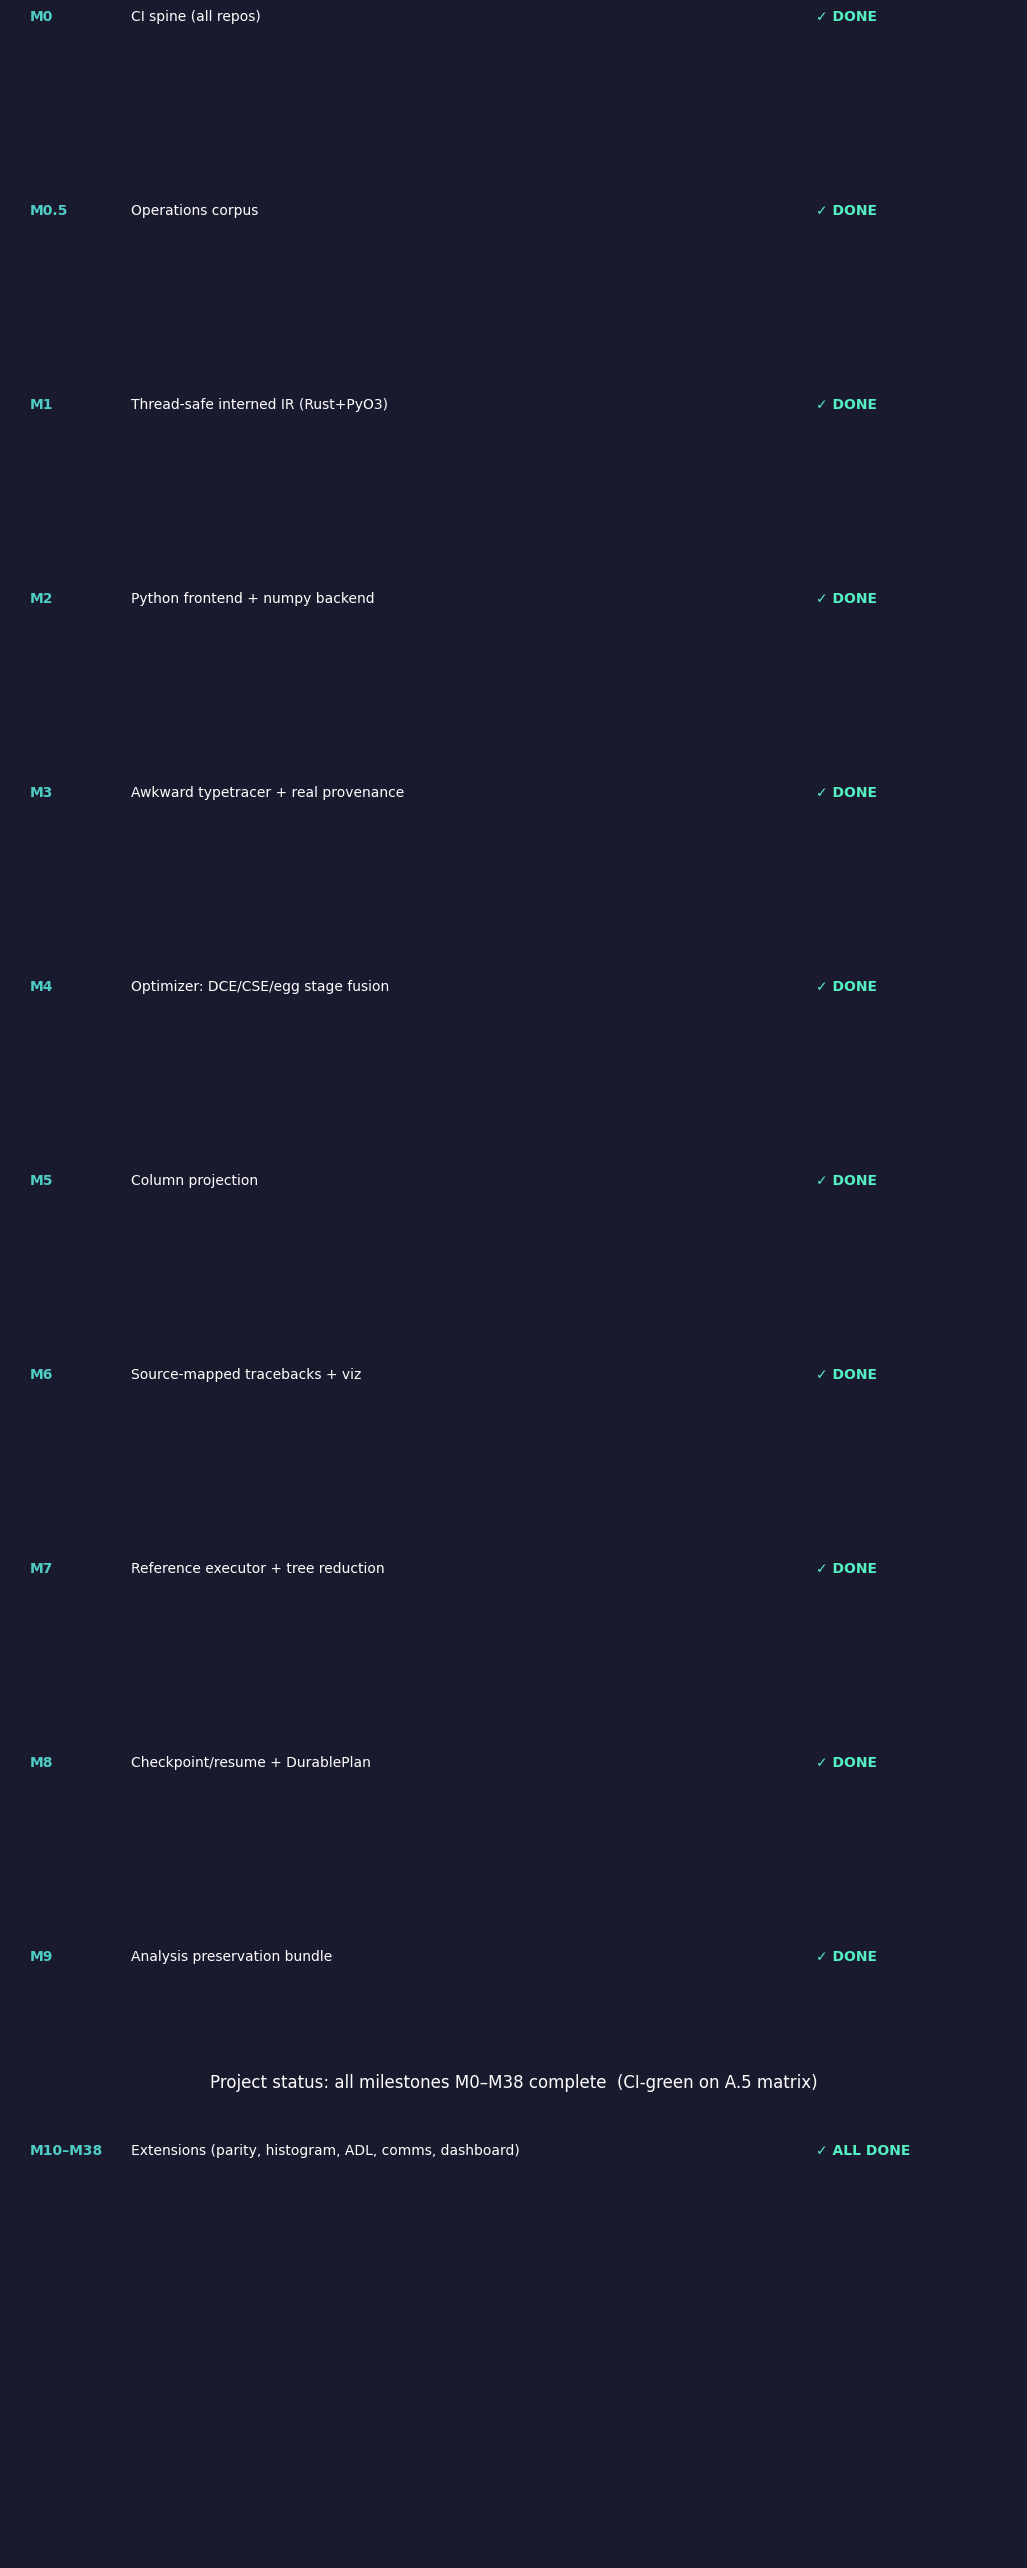

In [17]:
fig, ax = plt.subplots(figsize=(13, 6))
ax.axis("off")

milestones = [
    ("M0",  "CI spine (all repos)",                  "✓ DONE"),
    ("M0.5","Operations corpus",                     "✓ DONE"),
    ("M1",  "Thread-safe interned IR (Rust+PyO3)",   "✓ DONE"),
    ("M2",  "Python frontend + numpy backend",       "✓ DONE"),
    ("M3",  "Awkward typetracer + real provenance",  "✓ DONE"),
    ("M4",  "Optimizer: DCE/CSE/egg stage fusion",   "✓ DONE"),
    ("M5",  "Column projection",                     "✓ DONE"),
    ("M6",  "Source-mapped tracebacks + viz",        "✓ DONE"),
    ("M7",  "Reference executor + tree reduction",   "✓ DONE"),
    ("M8",  "Checkpoint/resume + DurablePlan",       "✓ DONE"),
    ("M9",  "Analysis preservation bundle",          "✓ DONE"),
    ("M10–M38", "Extensions (parity, histogram, ADL, comms, dashboard)", "✓ ALL DONE"),
]

colors_m = ["#55efc4"] * len(milestones)
for i, (mid, desc, status) in enumerate(milestones):
    y = 5.5 - i * 0.42
    ax.text(0.02, y, mid, fontsize=10, fontweight="bold", color="#4ecdc4",
        transform=ax.transAxes, va="center")
    ax.text(0.12, y, desc, fontsize=10, color="white", transform=ax.transAxes, va="center")
    ax.text(0.80, y, status, fontsize=10, color="#55efc4", fontweight="bold",
        transform=ax.transAxes, va="center")

ax.set_title("Project status: all milestones M0–M38 complete  (CI-green on A.5 matrix)",
    color="white", fontsize=12)
plt.tight_layout()
plt.show()

## Phase 2: What's Not in the MVP

The MVP is deliberately scoped. Phase 2 plans:

| Item | Status |
|---|---|
| Swap `egg` → `egglog` behind `RewriteEngine` | The trait is ready; engine is swappable |
| TaskVine / HTCondor / Slurm executors | `Executor` protocol is the seam |
| Predicate pushdown | Projection is conservative; no reorder across boundaries |
| Systematics-as-a-graph-axis | Requires IR shape extensions |
| Interactive debug / time-travel | `opt_level=0` is the debugging foundation |
| REANA / CAP / Zenodo / RECAST export | Preservation bundle is the content-addressed base |
| Adaptive reshaping | `next_tasks` protocol already in the contract |
| Free-threaded CPython 3.14t full CI | Building now; maturin + abi3 wheels ready |

<br>

**The design deliberately leaves these seams open** without building the Phase 2 machinery.
→ No over-engineering. No hypothetical abstractions.

## Conclusion

### What we built
A complete, production-quality HEP task-graph system in 11 packages:

- **IR in Rust** with hash-consing, equality saturation (egg), stage fusion
- **Python frontend** with deferred proxies, typetracer-based type inference, provenance
- **Awkward-array backend** with automatic column projection
- **Reference executor** with tree reduction and straggler tolerance
- **Content-addressed checkpointing** with crash-safe resume
- **Source-mapped tracebacks** that survive process boundaries
- **Analysis preservation bundles** for long-term reproducibility

### Key outcomes
- All 8 ADL benchmark queries pass bit-for-bit vs. coffea
- Near-linear scaling to 8 workers on I/O+compute queries
- O(1) graph size (incremental reduction as you build)
- Zero cloudpickle in the canonical representation

### The key insight
> Reduce eagerly, intern aggressively, serialize the IR — not closures.
> Every design decision flows from this.

---
**Code:** https://github.com/graphed-org · **Contact:** lagray@fnal.gov

# Backup Slides

## The Gated Development Pipeline

graphed is developed via a **3-role gated pipeline**, coordinated by `graphed-orchestrator`:

```
PENDING → DECOMPOSE → TEST_AUTHORING → TEST_SANITY → FROZEN → IMPLEMENTING → REVIEW → DONE
```

**Three isolated agent contexts:**
- **test-author**: writes the acceptance suite for a milestone. Never sees implementation.
  Tests live in `tests/frozen/<Mx>/` — **frozen = read-only forever** after freeze tag.
- **implementer**: makes the frozen suite pass. May add `tests/extra/<Mx>/`.
  **May NEVER touch `tests/frozen/**`**. Logs each iteration to `.graphed/<Mx>/attempts.md`.
- **reviewer**: judges intent, guardrails, technique. May REJECT or APPROVE.

**Non-negotiable integrity rules:**
- Never edit, `skip`, `xfail`, or weaken a frozen test
- Never stub or mock the specific thing a test verifies
- Frozen tests must cover ≥90% of new/changed lines
- If a test seems wrong: file a **Test Dispute** and STOP

In [18]:
# Show the actual Rust NodeKey in Python via the pyi stub
print("NodeKey variants (from graphed-core/src/node.rs):")
print()
print('''
pub enum NodeKey {
    Source    { name: String, params: ParamMap },
    Op        { name: String, params: ParamMap, inputs: Vec<NodeId> },
    Reduction { name: String, params: ParamMap, inputs: Vec<NodeId> },
    External  { descriptor: PayloadDescriptor, params: ParamMap, inputs: Vec<NodeId> },
    Stage     { inputs: Vec<NodeId>, members: Vec<StageOp> },  // optimizer output
}

// Structural identity: two nodes with equal NodeKey intern to one NodeId
// Hash-consing is a Rust HashMap<NodeKey, NodeId>
// NodeId is u64
''')
print()
print("Boundary ops (do NOT fuse across these):")
import sys; sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed-awkward/src")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed/src")
from graphed_awkward import AwkwardBackend
b = AwkwardBackend()
print(f"  AwkwardBackend.boundary_ops() = {b.boundary_ops()}")

NodeKey variants (from graphed-core/src/node.rs):


pub enum NodeKey {
    Source    { name: String, params: ParamMap },
    Op        { name: String, params: ParamMap, inputs: Vec<NodeId> },
    Reduction { name: String, params: ParamMap, inputs: Vec<NodeId> },
    External  { descriptor: PayloadDescriptor, params: ParamMap, inputs: Vec<NodeId> },
    Stage     { inputs: Vec<NodeId>, members: Vec<StageOp> },  // optimizer output
}

// Structural identity: two nodes with equal NodeKey intern to one NodeId
// Hash-consing is a Rust HashMap<NodeKey, NodeId>
// NodeId is u64


Boundary ops (do NOT fuse across these):
  AwkwardBackend.boundary_ops() = frozenset({'ak.count', 'onnx', 'source', 'ak.all', 'correction', 'external', 'ak.sum', 'map', 'ak.any'})


## egg: Implementation Details in graphed-core

**The `RewriteEngine` trait:**
```rust
pub trait RewriteEngine {
    fn canonicalize(&self, graph: &EngineGraph) -> EngineGraph;
}
```
`EngineGraph` is egg-free (just `Vec<EngineNode>` + `outputs`).
No egg types leak past this boundary → Phase 2 swap is mechanical.

**The rule set (sound only):**
```rust
// Generated from SYMMETRIC_OPS: [add, mul, and, or, eq, ne, maximum, minimum]
// Commutativity: (op|add ?a ?b) ↔ (op|add ?b ?a)
// Identity: (op|add|scalar=0.0;side=sr ?x) → ?x
//           (op|mul|scalar=1.0;side=sr ?x) → ?x
```

**Extraction is O(N):**
Since our rules only ever promote an existing *earlier* node (commutativity picks the first),
we extract by quotienting the IR by e-graph equivalence classes and keeping the node with the
smallest original id. egg's default recursive Extractor is O(depth × nodes) — O(N²) on deep
chains — so we use this custom O(N) approach.

**Saturation budget:** `iter_limit` (deterministic, no wall-clock timeout).

## Incremental Reduction (M10)

**The problem:** without incrementality, `Session.serialized_ir()` does a whole-history optimization.
For a graph with N systematics variations, that's O(N) work every time the user adds one op.

**`IncrementalReducer`:**
```python
reducer = graphed_core.IncrementalReducer()
# After each recorded op:
reducer.step(store)   # canonicalizes only the DELTA since last step
                      # total_work() proves per-step work is the delta
# At serialize time:
reducer.finalize(store, outputs=[...])  # one linear pass from the watermark
```

**Key invariant:** `total_work() == sum of per-step deltas` (not the history).
Proven by the M10 frozen test: building an N-node graph takes O(N) total reducer work.

**Consequence:** O(1) IR size — a large un-reduced graph never accumulates in memory.
This is the direct fix for dask failure #3 (slow optimization dominating wall time).

## The Awkward Typetracer

awkward-array ships a **typetracer**: a metadata-only array object that:
- Has the same API surface as a real `ak.Array`
- Records which data buffers are "touched" during array operations
- Returns arrays whose values are `UnknownLength`, `UnknownType` sentinel objects
- Never reads any actual data

graphed reuses this **verbatim** for type inference:

```python
# Inside AwkwardBackend.op_form("zip", [form_pt, form_eta], {}):
typetracer_pt  = ak.Array(form_pt.type.length_zero_array().layout.to_typetracer())
typetracer_eta = ak.Array(form_eta.type.length_zero_array().layout.to_typetracer())
result = ak.zip({"pt": typetracer_pt, "eta": typetracer_eta})
return AwkwardForm(type_str=str(result.type))
```

The **same typetracer walk** is used for column projection:
rather than recording which fields are `touched`, we record the buffer access log.

**"Reuse, don't reinvent"** — awkward already solved HEP array type inference.
graphed benefits from every awkward improvement automatically.

## Column Projection Algorithm

**Input:** a compiled graph + a source name
**Output:** `frozenset[str]` of NanoAOD branch names needed

```python
def read_columns(session: Session, output: Array, source_name: str) -> frozenset[str]:
    # 1. Walk the graph from output to sources via the IR
    # 2. For each Op encountered, run typetracer evaluation
    # 3. Track which buffers of the source form are touched
    # 4. Return the set of touched branch names
```

**Conservative fallback:** if a node uses an opaque callable (cloudpickle External)
→ `CONSERVATIVE`: return ALL columns. The node is flagged `opaque=True`.

**Proof that projection is correct:**
The frozen M5 suite checks that the projected set for each ADL query is:
1. Sufficient: the query runs without error on a file that has ONLY those branches
2. Necessary: removing any projected branch causes a KeyError

This means the I/O savings are real, not approximate.

## Executor Internals

**`ThreadExecutor`:**
- `concurrent.futures.ThreadPoolExecutor`
- Correct with GIL-free awkward (3.14t: full concurrency)
- File locality: `open_once` cache per worker thread

**`ProcessPoolExecutor` (the default for HEP workloads):**
- Process-isolated workers (no shared state except IPC)
- Each worker inherits the full queue registry (O(N) per process, the right default up to ~fd limit)
- Peer-reduction via IPC/HTTP transport (M38): workers combine locally before sending to driver
- File locality: `open_once` per process (uproot file handle cached)

**`PinnedPoolExecutor`:**
- Same as ProcessPoolExecutor but each worker is pinned to an O(log N) overlay
- O(N log N) total registry for large many-core machines
- Use when: worker count > ~1000

**Work stealing (M38):**
When a worker finishes early, it contacts a straggler via the peer transport
and requests a subset of its remaining partitions → no straggler tail.

## Tree Reduction: Determinism Despite Non-Deterministic Completion

**The problem:**
Workers complete in non-deterministic order. If we accumulate partials left-to-right,
different runs produce different floating-point results (due to FP non-commutativity).

**The solution:**
Each `Task` has a deterministic integer `key` (its position in the fixed partition list).
The tree reduction shape is determined by `key` — not completion order.

```python
def plan_tree(tasks: Sequence[Task]) -> list[tuple[int, int]]:
    # Sort tasks by key. Pair adjacent keys. The pairs determine the reduction tree.
    # A task that arrives early is buffered until its pair arrives.
    # A straggler never blocks: paired with a partial from an already-finished sibling.
```

**`running_fold`** implements the non-blocking accumulation:
as each partial arrives (keyed by task.key), fold it into the current running tree.

**Result:** the final histogram is byte-for-byte identical across all runs
with the same partition list, regardless of network latency or worker scheduling.

## Checkpoint Store: Journal Format

**Layout (local filesystem):**
```
store/
├── journal.jsonl           # append-only; one entry per committed task
├── objects/
│   ├── sha256:abc123/      # one directory per task_id
│   │   └── partial.pkl     # the partial result (codec-encoded)
│   └── …
└── dead_letters/
    └── sha256:xyz789.json  # dead-letter descriptor
```

**Journal entry:**
```json
{"task_id": "sha256:abc123", "committed_at": 1719340800, "entries": 8192, "status": "ok"}
```

**Atomicity:**
The partial is written to a temp file, then `os.replace()` atomically renames it.
The journal entry is only written after the rename succeeds.
→ A crash between write and journal = the object exists but is not journaled = will be re-run.
→ A crash after journal = idempotent on resume.

**Codec:**
`NumpyCodec` (for histogram arrays) or `PickleCodec` (fallback).
Pluggable: any object that rounds-trips via `encode(partial) → bytes` / `decode(bytes) → partial`.

## Dead-Letter Handling and Retry Policies

**When a partition fails:**

1. `RetryN(n)`: retry up to N times before dead-lettering
2. `RetryElsewhere`: re-queue on a different worker (e.g. if I/O error is site-specific)
3. `RetrySmallerChunk`: split the failing partition into smaller sub-partitions and retry
4. `Quarantine`: dead-letter immediately (for deterministically bad data)

**Dead-letter descriptor:**
```python
{
    "task_id":    "sha256:...",
    "partition":  {"uri": "...", "tree": "Events", "entry_start": 0, "entry_stop": 8192},
    "error":      "IndexError: too many muons",
    "traceback":  "...",   # serialized StageError if available
    "attempts":   3,
}
```

**Error budget:** `StopCondition.max_errors = N`
→ if N partitions dead-letter, stop the run and return what we have.
The dead-letter set is a reproducible, content-addressed record of what failed.

**`reproduce()` in the preservation bundle** is dead-letter aware:
it skips partitions in the dead-letter set (known-bad) and returns the same partial.

## StageError: Picklable Across a Process Boundary

**The problem:**
Python's standard `Exception.__reduce__` includes the traceback object,
which may hold references to non-picklable objects (local variables, file handles, …).
`concurrent.futures` workers propagate exceptions by pickling them.
→ A non-picklable StageError degrades to an opaque `ExceptionInfo` string.

**graphed's solution:**
`StageError` implements `__reduce__` and `__setstate__` to store only plain data:

```python
class StageError(Exception):
    frame: SourceFrame          # (filename, lineno, expression_text)
    op:    str                  # the failing op name
    partition: str              # which partition failed
    inputs: list[str]           # form descriptions of inputs
    # NO traceback object — that's the non-picklable part

    def __reduce__(self):
        return (_rebuild_stage_error, (self.frame, self.op, self.partition, self.inputs))
```

**Proven by the frozen M6 test:**
`format_traceback(pickle.loads(pickle.dumps(err))) == format_traceback(err)` — identical output
before and after a round-trip through pickle.

## Preservation Bundle: Plugin System

```python
@dataclass
class ExternalPlugin:
    kind: str                   # e.g. "onnx_model", "correctionlib", "histogram"
    content_hash: Callable      # (payload: bytes) -> str  — deterministic, content-based
    evaluate: Callable          # (payload: bytes, inputs: list) -> object
    io_schema: str              # human-readable description

register_plugin(ONNX_PLUGIN)
register_plugin(CORRECTIONLIB_PLUGIN)
register_plugin(HISTOGRAM_PLUGIN)
register_plugin(PYTORCH_PLUGIN)   # TorchScript model
register_plugin(TENSORFLOW_PLUGIN)
register_plugin(JAX_PLUGIN)       # jax.export
register_plugin(XGBOOST_PLUGIN)
register_plugin(TRITON_PLUGIN)    # inference server endpoint
```

**Non-vacuous content_hash validation:**
The orchestrator tests each plugin's `content_hash` by:
1. Generating a random payload
2. Checking `content_hash(payload) != content_hash(mutated_payload)`
→ proves the hash actually changes when content changes (not a constant hash)

**`inspect()` without executing:**
reads the manifest + IR to describe inputs, outputs, and external nodes
without materializing any computation.

## ADL Query 6: The Trijet Challenge

```python
def q6(g):
    # Find the trijet system whose invariant mass is closest to 172.5 GeV (top quark mass)
    j = jets(g)
    # All C(n_jets, 3) combinations per event — O(n³) per event, ragged
    trijet = gak.combinations(j, 3, fields=["j1", "j2", "j3"])
    trijet["p4"] = (trijet["j1"] + trijet["j2"] + trijet["j3"])  # 4-vector sum
    trijet["mass"] = trijet["p4"].mass
    # Per-event argmin: find the combination closest to top mass
    closest = trijet[gak.argmin(np.abs(trijet["mass"] - 172.5), axis=1)]
    # Max pT jet of the winning triple
    max_pt_j = gak.argmax(gak.Array([
        closest["j1"].pt, closest["j2"].pt, closest["j3"].pt
    ], axis=0), axis=0)
    return hg.Hist.new.Reg(100, 15, 40).Double().fill(trijet_pt=max_pt_j)
```

**Why q6 is expensive:**
- `ak.combinations(j, 3)` materializes C(n,3) rows per event
- For multi-jet events: 4 jets → 4 triples, 10 jets → 120 triples
- Each triple carries three 4-vectors → large intermediate arrays
- Peak memory usage is O(n_jets³) per chunk → memory-bandwidth bound at high parallelism

**q6 performance note:**
Slower at 8 workers (167s) than 4 (113s) on this machine — all 8 workers simultaneously
materializing large C(n,3) intermediates compete for memory bandwidth.
Fix: smaller chunk size for combinatoric queries (a per-query chunk policy, Phase 2).

## Full Benchmark Results: 53.4M Events

| Query | Bytes read | 1w (s) | 4w (s) | 8w (s) | @4 speedup | @8 speedup | b/event |
|---|---|---|---|---|---|---|---|
| q1 (MET)              | 0.23 GB | 1.9  | 2.0   | 1.8   | ~1x (driver-bound) | ~1x | 4.3 |
| q2 (jet pT)           | 0.75 GB | 5.6  | 1.6   | 1.1   | **3.5x** | **5.2x** | 14 |
| q3 (jet pT, \|η\|<1)  | 1.54 GB | 13.4 | 3.7   | 2.3   | **3.7x** | **5.8x** | 29 |
| q4 (MET + ≥2 jets)    | 0.98 GB | 7.6  | 2.1   | 1.4   | **3.7x** | **5.6x** | 18 |
| q5 (dimuon mass)      | 1.57 GB | 16.9 | 4.6   | 3.2   | **3.7x** | **5.3x** | 29 |
| q6 (trijet)           | 3.52 GB | 181.9| 112.9 | 166.6 | 1.6x | 1.1x (see note) | 66 |
| q7 (jet+muon dR)      | 4.75 GB | 56.0 | 15.9  | 9.7   | **3.5x** | **5.8x** | 89 |
| q8 (SFOS + MT)        | 2.14 GB | 26.7 | 7.5   | 4.7   | **3.6x** | **5.7x** | 40 |

Machine: macOS arm64, local SSD, chunksize 2¹⁹ (102 chunks/run), persistent process pools.
All counts validated bit-for-bit vs coffea on the 50k acceptance skim.
q6 memory-bandwidth note: smaller chunks → better scaling for combinatoric queries.

## The Corpus Operations Catalog (graphed-corpus)

A **backend-agnostic** catalog of required operations for HEP analyses, with:
- Reference implementations against test fixtures
- Canonical expected output values (bit-for-bit pinned)
- Analyses that each backend must pass

**Categories:**
| Category | Examples |
|---|---|
| Arithmetic | add, sub, mul, div, pow, abs, neg, min/max |
| Comparison | eq, ne, lt, le, gt, ge |
| Logical | and, or, not |
| Reduction | sum, prod, mean, std, var, any, all, argmin/argmax |
| Array ops | zip, combinations, concatenate, flatten, pad |
| Filtering | filter/mask, where |
| Field access | `array["field"]`, `array.field` |
| External | correctionlib, ONNX, histogram fill |
| HEP-specific | delta_phi, delta_r, 4-vector mass, combinations(n, k) |

The corpus is frozen: implementations must pass all corpus analyses exactly.
It is the acceptance criterion for every new backend.

## The Durable Plan and IR Serialization

**`DurablePlan` (in `graphed_core`):**
```python
@dataclass
class DurablePlan:
    ir:         bytes          # canonical serialized GraphStore (the optimized IR)
    process:    OpSpec         # worker function: import ref (not cloudpickle!)
    combine:    OpSpec         # associative combiner: import ref
    empty:      OpSpec         # identity element: import ref
    partitions: tuple[Partition, ...]  # the work list

    def ir_fingerprint(self) -> str:   # SHA-256 of ir bytes
    def task_id(self, partition) -> str  # SHA-256(ir + process + partition)
```

**`OpSpec` — the anti-cloudpickle:**
```python
@dataclass
class OpSpec:
    module: str       # "adl_graphed"
    qualname: str     # "make_backend"

    @classmethod
    def from_ref(cls, ref: str) -> "OpSpec":
        # "adl_graphed:make_backend"  →  OpSpec(module="adl_graphed", qualname="make_backend")

    def resolve(self) -> Callable:
        # importlib.import_module(self.module).__dict__[self.qualname]
```

No closures. No cloudpickle. Deterministic: the same `DurablePlan` bytes on any machine.

**Retargeting:**
```python
plan.for_dataset(Dataset("file://x.root", n_events=100), chunk_size=8192)
plan.with_partitions(partitions)
```

## Free-Threaded Python 3.14t Support

CPython 3.14 ships an optional **free-threaded** build (`python3.14t`) with no GIL.

**Why it matters for graphed:**
- `ThreadExecutor` with 3.14t = true parallel execution without process isolation overhead
- No serialization cost for worker input/output (shared memory)
- awkward-array is GIL-free (C++ kernels) → full benefit

**Build matrix (§A.5):**
```
OS × arch × CPython {3.11, 3.12, 3.13, 3.14, 3.14t}
```
`3.14t` is marked `experimental` in CI and does not block the gate.

**PyO3 + maturin support:**
```toml
# Cargo.toml
[features]
extension-module = ["pyo3/extension-module"]
abi3-py311 = ["pyo3/abi3-py311"]  # abi3 wheels for 3.11+
```
PyO3 ≥ 0.28 provides GIL-free bindings via `Python::with_gil()` → `unsafe { Python::assume_gil_acquired() }` for the 3.14t case.

**Current status:** builds and passes on 3.14t CI.
`ThreadExecutor` is the primary beneficiary; `ProcessPoolExecutor` already achieves parallelism.

## Multi-Output Analyses

A single pass over the data can fill **multiple histograms** from one compiled graph.

```python
session = Session(AwkwardBackend())
events = from_awkward(session, "events", ...)

# Two histograms, one pass:
h_met = hg.Hist.new.Reg(100, 0, 200).Double().fill(met=events.MET_pt)
h_njet = hg.Hist.new.Reg(15, 0, 15).Double().fill(njet=ak.num(events.Jet_pt))

# Compile BOTH outputs into one graph → one pass over the data
plan = graphed_core.DurablePlan(
    ir=session.serialized_ir(h_met, h_njet),   # both outputs
    ...
)
```

The optimizer's DCE step reachability is from **all outputs**, so common subexpressions
(e.g. reading `events.MET_pt`) are shared across the two histograms automatically.

**q6 in the ADL suite** already does this: two histograms (`trijet_pt` + `trijet_mass`)
are both in a single multi-output compile → one read of the 3.52 GB of branches.

## Live Dashboard (M37)

During a long run, graphed-debug provides a live monitoring interface:

```python
from graphed_debug import Dashboard, DashboardServer

server = DashboardServer(host="0.0.0.0", port=8765)
server.start()

# In the executor:
executor.run(plan, monitor=server.monitor)
# → opens http://localhost:8765  (FINOS Perspective table + WebSocket feed)
```

**What it shows:**
- Task phase (queued → in_progress → done / failed)
- Per-worker throughput (events/s, MB/s)
- Straggler detection
- Dead-letter count

**Architecture:**
- `graphed_core.emit_task(ctx, event)` — the passive Monitor seam in core
- `graphed_exec_local` calls `emit_task` at each phase transition
- `DashboardServer` is a WebSocket server that broadcasts TaskEvent JSON
- FINOS Perspective renders the live table in the browser

The monitor seam is opt-in and additive — no overhead when not connected.

## Inter-Worker Communications (M38)

**Peer reduction:** workers reduce their own partial results locally before sending to the driver.

```
Without peer reduction:          With peer reduction (IPC):
  w1 → partial1 → driver            w1 ─┐
  w2 → partial2 → driver            w2 ─┼→ peer reduce → driver
  w3 → partial3 → driver            w3 ─┘
  → N round trips to driver         → O(log N) round trips
```

**`WorkerTransport` seam (in `graphed_core`):**
```python
class WorkerTransport(Protocol):
    def send(self, peer_id: int, partial: bytes) -> None: ...
    def recv(self, timeout_s: float) -> bytes | None: ...
```

**Two backends:**
- `IpcTransport` — POSIX shared-memory queues (the default, `comms="ipc"`)
- `HttpTransport` — HTTP/1.1 server per worker (for process isolation without shared memory)

**Work stealing (M38):**
A fast worker queries its IPC queue for straggler partitions and claims them.
The straggler is notified and drops the claimed partition from its queue.
→ no tail latency from stragglers on the critical path.

## Comparison: graphed vs Existing Tools

| Property | dask-awkward | coffea 2025 | **graphed** |
|---|---|---|---|
| Schedulable task graph | ✓ | ✗ (dropped) | ✓ |
| Graph optimization before run | ✗ (O(N²)) | N/A | ✓ O(N) incremental |
| Serializable IR (not cloudpickle) | ✗ | N/A | ✓ content-addressed |
| Column projection | partial | manual | ✓ automatic (typetracer) |
| Crash-safe resume | ✗ | ✗ | ✓ content-addressed store |
| Source-mapped tracebacks | ✗ | partial | ✓ across process boundary |
| Analysis preservation bundle | ✗ | ✗ | ✓ bit-for-bit reproducible |
| HEP standards (correctionlib, ONNX) | external | external | ✓ built-in plugins |
| IR-based (not cloudpickle) | ✗ | N/A | ✓ |
| Free-threaded 3.14t | ✗ | ✗ | ✓ (experimental) |

**graphed is NOT a replacement for coffea** — it is the *task-graph layer* underneath coffea.
The goal: a coffea user writes the same analysis code; graphed handles scheduling, optimization,
checkpointing, debugging, and preservation transparently.

## References

**graphed-org repositories**
https://github.com/graphed-org

**Equality Saturation / egg**
Willsey, Nandi, Wang, Flatt, Tatlock, Panchekha.
*egg: Fast and Extensible Equality Saturation.* POPL 2021.
https://arxiv.org/abs/2004.03082

**awkward-array**
Pivarski et al. *Awkward Array.* CHEP 2019 / JACoW 2020.
https://arxiv.org/abs/2001.06307

**coffea / ADL benchmarks**
Gray et al. *Coffea: Columnar Object Frameworks for Fast Analysis.*
CHEP 2019; ADL benchmark suite: https://github.com/cms-opendata-analyses/ADLBenchmark

**correctionlib**
https://github.com/cms-nanoAOD/correctionlib

**boost-histogram / UHI**
Schreiner et al. *boost-histogram.* PyHEP 2020.
https://github.com/scikit-hep/boost-histogram

**ONNX Runtime**
https://github.com/microsoft/onnxruntime

**Free-threaded Python (PEP 703)**
https://peps.python.org/pep-0703/

**PyO3 (Rust↔Python bindings)**
https://github.com/PyO3/pyo3

## The Optimizer: Rust Pipeline Step by Step

Located in `graphed-core/src/optimizer/mod.rs`.

### Step 1: DCE — `dead_code_elimination(nodes, outputs)`
```rust
// Plain reachability: mark nodes on any path from a source to an output.
// Pop from a stack; mark; push unmarked inputs. O(N).
// Un-marked nodes are silently dropped (never reached by the user's outputs).
```

### Step 2: Canonicalize — `engine.canonicalize(eg: &EngineGraph)`
```rust
// Load the DCE'd nodes into an egg EGraph<SymbolLang, ()>
// Each node becomes a SymbolLang expression: "op|add node_a node_b"
// Run Runner::run_until_saturated() with the rule set (commutativity, identities)
// The e-graph is now partitioned into equivalence classes
// Extract: for each e-class, pick the node with the SMALLEST original index
//   (O(N) — equivalent to: prefer the form recorded first, i.e. the canonical topological form)
```

### Step 3: CSE — `cse(canonical)`
```rust
// Re-hash all (token, inputs) pairs in the canonicalized graph.
// Identical pairs (can only arise if egg merged two separately-recorded sub-exprs) → one node.
// This is O(N) and re-asserts the M1 hash-consing property post-canonicalization.
```

### Step 4: Stage Fusion — `stage_fusion(deduped, templates, mode)`
```rust
// Walk topological order. For each Op node:
//   - if its inputs are all already in one stage AND it is not a boundary → extend that stage
//   - Maximal mode: if ALL consumers of an op land in one stage → the op also fuses (fan-out safe)
// A Stage node packages: inputs (external node ids) + members (self-contained StageOp DAG)
```

In [19]:
import sys
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/.venv/lib/python3.12/site-packages")
sys.path.insert(0, "/Users/lgray/vibe-coding/graphed-workdir/graphed/tests/frozen/m2")
import json, graphed_core
from graphed import Session
from backends import ListBackend, from_list

# Build and serialize a small analysis
s = Session(ListBackend())
a = from_list(s, "a", [1, 2, 3])
b = from_list(s, "b", [4, 5, 6])
result = (a + b) * a

ir_bytes = s.serialized_ir(result, optimize=True)
print(f"Serialized IR size: {len(ir_bytes)} bytes")
print(f"Format: MessagePack (deterministic, versioned, binary)")
print()

# Deserialize and introspect
store_back = graphed_core.GraphStore.deserialize(ir_bytes)
print("Nodes in deserialized store (structured view):")
for nd in store_back.nodes():
    print(f"  {nd}")
print()
print("Outputs:", store_back.outputs())
print()
print("Key properties of the serialized IR:")
print("  • Schema-versioned: incompatible changes bump the version; old IR rejected loudly")
print("  • Deterministic: same analysis on any machine → byte-identical bytes")
print("  • Self-contained: no Python objects, no closures, no cloudpickle")
print("  • Content-addressed: SHA-256 of ir_bytes = task fingerprint")

Serialized IR size: 113 bytes
Format: MessagePack (deterministic, versioned, binary)

Nodes in deserialized store (structured view):
  {'id': 0, 'output': False, 'inputs': [], 'kind': 'source', 'name': 'a', 'params': {}}
  {'id': 1, 'output': False, 'inputs': [], 'kind': 'source', 'name': 'b', 'params': {}}
  {'id': 2, 'output': True, 'inputs': [0, 1], 'kind': 'stage', 'name': '', 'params': {}, 'n_members': 2, 'members': [{'kind': 'op', 'name': 'add', 'params': {}, 'inputs': [('input', 0), ('input', 1)]}, {'kind': 'op', 'name': 'mul', 'params': {}, 'inputs': [('member', 0), ('input', 0)]}]}

Outputs: [2]

Key properties of the serialized IR:
  • Schema-versioned: incompatible changes bump the version; old IR rejected loudly
  • Deterministic: same analysis on any machine → byte-identical bytes
  • Self-contained: no Python objects, no closures, no cloudpickle
  • Content-addressed: SHA-256 of ir_bytes = task fingerprint
